In [1]:
from pathlib import Path

PREP_ROOT = Path(r"C:\Users\123wi\OneDrive\Desktop\duits uni\data analysis\preprocessing_streamed")
PREP_RUN_DIR = None  # None selects the newest COMPLETE preprocessing run.
NOTEBOOK_PATH = PREP_ROOT.parent / "complaints_analysis.ipynb"
print("Preprocessing folder:", PREP_ROOT)

Preprocessing folder: C:\Users\123wi\OneDrive\Desktop\duits uni\data analysis\preprocessing_streamed


# Complaint analysis: LSA, LDA, BERTopic and NMF
Here we find common themes in the complaints and compare four locally running topic models.
We read **complaints.jsonl from the preprocessing pipeline** and expand contractions before rebuilding features.
**No stemming or stop-word removal. No API keys or per-request charges.**

Save this file as `complaints_analysis.ipynb` beside your preprocessing notebook and use your Python 3.10 Conda kernel.
Restart the kernel and run the cells in order. Use a new analysis run rather than resuming an older model configuration.

### Install once, then restart the kernel
Run this in a temporary cell if libraries are missing. NMF is included in scikit-learn.
```python
%pip install "numpy==1.26.4" "pandas>=2.2,<3" "scipy>=1.11,<1.16" "scikit-learn>=1.5,<1.8" "nltk>=3.9.1,<4" "joblib>=1.4,<2" "psutil>=5.9,<8" "matplotlib>=3.8,<3.11" "seaborn>=0.13,<0.14" "torch>=2.2,<2.7" "sentence-transformers>=3.2.1,<4" "transformers>=4.41,<4.50" "bertopic>=0.16.4,<0.18" "umap-learn>=0.5.7,<0.6" "hdbscan>=0.8.38,<0.9" "nbformat>=5.10,<6" "nbconvert[webpdf]>=7.16,<8"
```
First use downloads language resources and the embedding model. PDF export may download Chromium.
The notebook prints whether PyTorch detects CUDA. An NVIDIA card requires a compatible CUDA-enabled PyTorch installation to be used.

### Scope of the experiment
We sample across the entire saved corpus without loading it all into RAM.
The defaults are **100,000 training complaints and 1,000 held-out complaints**, shared by all four models.
These are starting settings for your 32 GB laptop, not a guarantee of peak memory use.
The training vocabulary retains at most 100,000 terms. Common words are not explicitly removed.

Full-corpus prediction is enabled: after comparison, all four fitted models assign every saved complaint in small batches.
**The models are trained on the sample; full-corpus prediction does not refit them on all rows.**
The batch stage can take a long time. Saved checkpoints support resuming it with the same fitted models.


## 1. Settings
Here we choose a larger training sample and small processing batches.
The original preprocessing files are preserved. Word matrices stay sparse.
BERTopic uses your GPU for embeddings when CUDA is available; the other model implementations use the CPU.
Keep other large notebooks closed to leave RAM available. Lower TRAIN_DOCS or batch sizes if needed.


In [2]:
import gc, hashlib, importlib, json, os, random, re, subprocess, sys, time, uuid
from collections import Counter
from datetime import datetime, timezone
from importlib.metadata import version, PackageNotFoundError
from itertools import islice

import nltk
import numpy as np
import pandas as pd
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import sparse
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation, MiniBatchNMF
from sklearn.preprocessing import normalize
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
from joblib.externals.loky import ProcessPoolExecutor
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

KEEP_WORDS = {"no", "not", "nor", "never", "without"}
STOP_WORDS = sorted(set(ENGLISH_STOP_WORDS) - KEEP_WORDS)

SEED = 42
TRAIN_DOCS = 1_200_000
EVAL_DOCS = 1_000
N_LDA_TOPICS = 12
N_NMF_TOPICS = 12
NMF_BATCH_ROWS = 1024
NMF_MAX_ITER = 30
N_LSA_COMPONENTS = 6  # Two signed poles per component: up to 12 themes.
MAX_FEATURES = 100_000  # Most frequent training terms; no stop-word removal.
N_WORKERS = max(1, min(4, (psutil.cpu_count(logical=False) or 2) - 1))
TEXT_BATCH = 32
EMBED_BATCH = 64
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
BER_MIN_TOPIC_SIZE = 100
RUN_FULL_CORPUS_ASSIGNMENT = True  # Optional, potentially long: local models only.
FULL_BATCH_ROWS = 512
# To resume a previous analysis run, paste its directory here. Keep settings unchanged.
RESUME_ANALYSIS_DIR = None

pd.set_option("display.max_colwidth", 100)
random.seed(SEED)
np.random.seed(SEED)
MODEL_RESULTS = {}
MODEL_STATUS = {}

print("Python:", sys.version.split()[0], "| Workers:", N_WORKERS)
print("Requested train / held-out rows:", TRAIN_DOCS, "/", EVAL_DOCS)
print("Stop-word removal: enabled for word features. Stemming: disabled.")
print("Available RAM:", round(psutil.virtual_memory().available / 1024**3, 2), "GiB")

Python: 3.10.21 | Workers: 4
Requested train / held-out rows: 1200000 / 1000
Stop-word removal: enabled for word features. Stemming: disabled.
Available RAM: 18.02 GiB


## 2. Find the saved preprocessing output
Here we choose a completed run and check its metadata. Original text must have been retained
because we need to expand contractions before creating new word features. Old TF-IDF and count
shards describe the old text, so we rebuild the analysis features inside this new analysis folder.

In [3]:
def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

def write_json(path, value):
    path = Path(path)
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(json.dumps(value, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
    temporary.replace(path)

def completed_runs(root):
    found = []
    for p in root.glob("run_*/preprocessing_status.json"):
        try:
            if read_json(p).get("status") == "complete" and (p.parent / "complaints.jsonl").is_file():
                found.append(p.parent)
        except (OSError, ValueError):
            continue
    return sorted(found, key=lambda p: (p / "preprocessing_status.json").stat().st_mtime)

if PREP_RUN_DIR is None:
    available = completed_runs(PREP_ROOT)
    if not available:
        raise FileNotFoundError(f"No completed preprocessing run under {PREP_ROOT}")
    PREP_RUN_DIR = available[-1]
else:
    PREP_RUN_DIR = Path(PREP_RUN_DIR)
prep_info = read_json(PREP_RUN_DIR / "preprocessing_status.json")
if prep_info.get("status") != "complete":
    raise RuntimeError("This preprocessing run is incomplete. Select a completed run.")
JSONL_PATH = PREP_RUN_DIR / "complaints.jsonl"
if not JSONL_PATH.is_file():
    raise FileNotFoundError(JSONL_PATH)

ANALYSIS_ROOT = PREP_ROOT.parent / "analysis_results"
OUT_DIR = (Path(RESUME_ANALYSIS_DIR) if RESUME_ANALYSIS_DIR else
           ANALYSIS_ROOT / (datetime.now(timezone.utc).strftime("run_%Y%m%d_%H%M%S_") + uuid.uuid4().hex[:6]))
OUT_DIR.mkdir(parents=True, exist_ok=True)
for folder in ["tables", "figures", "models", "sample", "full_corpus"]:
    (OUT_DIR / folder).mkdir(exist_ok=True)
CONFIG = {
    "source_jsonl": str(JSONL_PATH.resolve()), "source_bytes": JSONL_PATH.stat().st_size,
    "source_mtime_ns": JSONL_PATH.stat().st_mtime_ns, "seed": SEED,
    "train_docs": TRAIN_DOCS, "eval_docs": EVAL_DOCS, "max_features": MAX_FEATURES,
    "nmf_topics": N_NMF_TOPICS, "nmf_batch_rows": NMF_BATCH_ROWS, "nmf_max_iter": NMF_MAX_ITER,
    "lda_topics": N_LDA_TOPICS, "lsa_components": N_LSA_COMPONENTS,
    "embedding_model": EMBEDDING_MODEL, "ber_min_topic_size": BER_MIN_TOPIC_SIZE,
    "stemming": False, "remove_stop_words": True,
}
if (OUT_DIR / "config.json").exists() and read_json(OUT_DIR / "config.json") != CONFIG:
    raise ValueError("Resume settings/source do not match this folder. Use a new analysis run.")
write_json(OUT_DIR / "config.json", CONFIG)
packages = {}
for name in ["numpy", "pandas", "scipy", "scikit-learn", "nltk", "sentence-transformers", "bertopic"]:
    try:
        packages[name] = version(name)
    except PackageNotFoundError:
        packages[name] = "not installed"
write_json(OUT_DIR / "environment.json", {"python": sys.version, "packages": packages})
print("Selected preprocessing run:", PREP_RUN_DIR)
print("Analysis output folder:", OUT_DIR)
print("Free output-disk space:", round(psutil.disk_usage(str(OUT_DIR)).free / 1024**3, 1), "GiB")
display(pd.Series(prep_info.get("stats", {}), name="Preprocessing totals").to_frame())
display(pd.Series(packages, name="Installed version").to_frame())

Selected preprocessing run: C:\Users\123wi\OneDrive\Desktop\duits uni\data analysis\preprocessing_streamed\run_20260923_103853_ac056b
Analysis output folder: C:\Users\123wi\OneDrive\Desktop\duits uni\data analysis\analysis_results\run_20260924_114526_79d8e5
Free output-disk space: 268.7 GiB


,Preprocessing totals
source_rows,3585952
missing_or_blank,2293687
duplicate_ids,0
empty_after_cleaning,59
kept_rows,1292206
total_tokens,215639113


,Installed version
numpy,1.26.4
pandas,2.3.3
scipy,1.15.3
scikit-learn,1.7.2
nltk,3.10.3
sentence-transformers,3.4.1
bertopic,0.17.4


## 3. Select a shared random sample
Here we use reservoir sampling. Every saved row has the same chance of entering the sample,
including rows near the end of the file. We split the sample into training and held-out rows.
We save the selected identifiers so that the comparison is reproducible. Product and issue labels
are kept only for inspection and are never supplied to the models.

In [4]:
def iter_records(path):
    with Path(path).open(encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, 1):
            if line.strip():
                try:
                    yield json.loads(line)
                except ValueError as exc:
                    raise ValueError(f"Invalid JSONL at line {line_number}") from exc

def write_jsonl(path, records):
    with Path(path).open("w", encoding="utf-8") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False, default=str) + "\n")

def reservoir_sample(path, size, seed):
    rng = random.Random(seed)
    selected = []
    count = 0
    for count, record in enumerate(iter_records(path), 1):
        if not isinstance(record.get("original_text"), str) or not record["original_text"].strip():
            raise ValueError("original_text is missing/blank. Re-run preprocessing with KEEP_ORIGINAL_TEXT=True.")
        if "matrix_row" not in record:
            raise ValueError("Expected matrix_row identifiers in preprocessing output.")
        if len(selected) < size:
            selected.append(record)
        else:
            j = rng.randrange(count)
            if j < size:
                selected[j] = record
        if count % 200_000 == 0:
            print(f"Scanned {count:,} rows; holding at most {size:,} rows.")
    rng.shuffle(selected)
    return selected, count

if TRAIN_DOCS < 20 or EVAL_DOCS < 10:
    raise ValueError("Use at least 20 training and 10 held-out rows.")
sampled, SOURCE_ROWS = reservoir_sample(JSONL_PATH, TRAIN_DOCS + EVAL_DOCS, SEED)
if SOURCE_ROWS < 50:
    raise ValueError("At least 50 preprocessed complaints are needed for this comparison.")
expected_rows = prep_info.get("stats", {}).get("kept_rows")
if expected_rows is not None and SOURCE_ROWS != expected_rows:
    raise ValueError("JSONL row count does not agree with the preprocessing status.")
actual_eval = min(EVAL_DOCS, max(10, len(sampled) // 5))
actual_train = len(sampled) - actual_eval
sample_df = pd.DataFrame.from_records(sampled)
sample_df["doc_id"] = sample_df["matrix_row"].astype(str)
if sample_df["doc_id"].duplicated().any():
    raise ValueError("Duplicate matrix_row identifiers in the sample.")
sample_df["split"] = ["train"] * actual_train + ["evaluation"] * actual_eval
keep = [c for c in ["doc_id", "matrix_row", "source_record", "complaint_id", "product", "issue", "original_text", "split"] if c in sample_df]
sample_df = sample_df[keep].copy()
del sampled
gc.collect()
sample_df.drop(columns="original_text").to_csv(OUT_DIR / "sample" / "selected_rows.csv", index=False)
print(f"Source rows: {SOURCE_ROWS:,}; training sample: {actual_train:,}; held-out sample: {actual_eval:,}")
print("Training and held-out rows are disjoint. Sampling does not remove duplicate narratives.")
display(sample_df.drop(columns="original_text").head())

Scanned 200,000 rows; holding at most 1,201,000 rows.
Scanned 400,000 rows; holding at most 1,201,000 rows.
Scanned 600,000 rows; holding at most 1,201,000 rows.
Scanned 800,000 rows; holding at most 1,201,000 rows.
Scanned 1,000,000 rows; holding at most 1,201,000 rows.
Scanned 1,200,000 rows; holding at most 1,201,000 rows.
Source rows: 1,292,206; training sample: 1,200,000; held-out sample: 1,000
Training and held-out rows are disjoint. Sampling does not remove duplicate narratives.


,doc_id,matrix_row,source_record,complaint_id,product,issue,split
0,1206714,1206714,3262110,3319298,Mortgage,Trouble during payment process,train
1,866598,866598,2197536,5734396,"Credit reporting, credit repair services, or other personal consumer reports",Improper use of your report,train
2,66323,66323,210261,1403441,Mortgage,"Loan servicing, payments, escrow account",train
3,824423,824423,2083439,4123642,"Credit reporting, credit repair services, or other personal consumer reports",Unable to get your credit report or credit score,train
4,1036316,1036316,2718200,3651549,Debt collection,Attempts to collect debt not owed,train


## 4. Expand contractions, then tokenise and lemmatise
Here we change `I'm` to `I am`, `wasn't` or `wasnt` to `was not`, and similar common forms.
We also expand clear forms such as `I've` and `we're`. The rules are conservative:
ordinary words such as `well`, `were`, `ill` and `its` are unchanged. Ambiguous `'s` and `'d`
forms are left unchanged rather than guessing between possessives, *is/has* and *had/would*.
This is not a grammar correction system, so unusual spelling may remain.

We keep expanded sentences for BERTopic. We use lowercase, POS-aware lemmas
for LSA and LDA. For example, `was not` may become `be not` after lemmatisation; the negation
is retained. Here we use a few separate processes to speed up lemmatisation on Windows.

In [5]:
WORKER_SOURCE = r'''
import html, re, unicodedata
from functools import lru_cache
import nltk
from nltk.stem import WordNetLemmatizer

EXACT = {
    "i'm": "i am", "can't": "can not", "cannot": "can not", 
    "won't": "will not", "wont": "will not", "shan't": "shall not", "shant": "shall not",
    "let's": "let us",
}
for base in ["is", "are", "was", "were", "do", "does", "did", "have", "has", "had", "could", "would", "should", "must", "need", "might"]:
    EXACT[base + "n't"] = base + " not"
    EXACT[base + "nt"] = base + " not"
# Ambiguous ain't is deliberately left unchanged.
for pronoun in ["i", "you", "we", "they"]:
    EXACT[pronoun + "'ve"] = pronoun + " have"
for pronoun in ["you", "we", "they"]:
    EXACT[pronoun + "'re"] = pronoun + " are"
for pronoun in ["i", "you", "he", "she", "it", "we", "they", "there", "that"]:
    EXACT[pronoun + "'ll"] = pronoun + " will"
_PATTERN = re.compile(r"(?<!\w)(?:" + "|".join(re.escape(k) for k in sorted(EXACT, key=len, reverse=True)) + r")(?!\w)", re.I)
_TOKEN = re.compile(r"[^\W\d_]+(?:'[^\W\d_]+)*")
_LEMMA = WordNetLemmatizer()
_POS = {"J": "a", "N": "n", "V": "v", "R": "r"}

def expand_contractions(text):
    text = unicodedata.normalize("NFKC", html.unescape(text))
    text = text.replace("\u2019", "'").replace("\u2018", "'")
    count = 0
    def replace(match):
        nonlocal count
        count += 1
        result = EXACT[match.group().lower()]
        if match.group()[0].isupper():
            result = result[0].upper() + result[1:]
        return result
    return _PATTERN.sub(replace, text), count

def clean_expanded(text):
    text, changes = expand_contractions(text)
    text = re.sub(r"</?[A-Za-z][^>]*>", " ", text)
    text = re.sub(r"(?i)\b(?:https?://|www\.)\S+", " ", text)
    text = re.sub(r"(?i)\b[\w.+-]+@[\w.-]+\.[a-z]{2,}\b", " ", text)
    text = re.sub(r"(?i)\bx{2,}\b", " ", text)
    return re.sub(r"\s+", " ", text).strip(), changes

def initialise_worker(data_paths):
    nltk.data.path[:] = data_paths
    nltk.corpus.wordnet.ensure_loaded()
    nltk.pos_tag(["ready"])

@lru_cache(maxsize=10_000)
def lemma(word, pos):
    return _LEMMA.lemmatize(word, pos)

def process_batch(texts):
    expanded = [clean_expanded(t) for t in texts]
    token_lists = [_TOKEN.findall(t.lower()) for t, n in expanded]
    tagged = nltk.pos_tag_sents(token_lists)
    results = []
    for (text, changes), sentence in zip(expanded, tagged):
        words = [lemma(w, _POS[tag[0]]) if tag[0] in _POS else w for w, tag in sentence]
        results.append({"expanded_text": text, "lemmatised_text": " ".join(words),
                        "expansion_count": changes, "token_count": len(words)})
    return results
'''
for resource, package in [("corpora/wordnet", "wordnet"), ("taggers/averaged_perceptron_tagger_eng", "averaged_perceptron_tagger_eng")]:
    try:
        nltk.data.find(resource)
    except LookupError:
        try:
            nltk.data.find(resource + ".zip")
        except LookupError:
            nltk.download(package, raise_on_error=True)

WORKER_PATH = OUT_DIR / "_analysis_text_worker.py"
WORKER_PATH.write_text(WORKER_SOURCE, encoding="utf-8")
if str(OUT_DIR) not in sys.path:
    sys.path.insert(0, str(OUT_DIR))
# Drop a previous run's module from this kernel before importing this helper.
sys.modules.pop("_analysis_text_worker", None)
importlib.invalidate_caches()
import _analysis_text_worker as text_worker

examples = ["I'm unhappy because it wasnt resolved.", "They won't refund me; I've asked twice.",
            "We were ill, but its terms were clear and well written.", "The bank's policy and he'd promised."]
display(pd.DataFrame({"Before": examples, "After": [text_worker.expand_contractions(x)[0] for x in examples]}))

def prepare_texts(texts, pool=None):
    batches = [texts[i:i + TEXT_BATCH] for i in range(0, len(texts), TEXT_BATCH)]
    if pool is None:
        chunks = map(text_worker.process_batch, batches)
    else:
        # Callers pass a bounded block so the executor cannot queue the full corpus.
        chunks = pool.map(text_worker.process_batch, batches)
    return [item for batch in chunks for item in batch]

prepared = []
started = time.perf_counter()
with ProcessPoolExecutor(max_workers=N_WORKERS, initializer=text_worker.initialise_worker,
                         initargs=(nltk.data.path,)) as pool:
    for start in range(0, len(sample_df), 512):
        prepared.extend(prepare_texts(sample_df.original_text.iloc[start:start + 512].tolist(), pool))
        if start % 2048 == 0:
            print(f"Expanded and lemmatised {min(start + 512, len(sample_df)):,}/{len(sample_df):,}")
sample_df = pd.concat([sample_df.reset_index(drop=True), pd.DataFrame(prepared)], axis=1)
del prepared
if (sample_df.token_count == 0).any():
    raise ValueError("Some sampled texts became empty. Inspect them before fitting the models.")
print("Contractions expanded:", int(sample_df.expansion_count.sum()))
print("Rows with an expansion:", int((sample_df.expansion_count > 0).sum()))
print("Text preparation minutes:", round((time.perf_counter() - started) / 60, 2))
display(sample_df[["original_text", "expanded_text", "lemmatised_text", "expansion_count"]].head(8))
write_jsonl(OUT_DIR / "sample" / "prepared_sample.jsonl", sample_df.to_dict("records"))
sample_df.drop(columns="original_text", inplace=True)
train_df = sample_df[sample_df.split == "train"].reset_index(drop=True).copy()
eval_df = sample_df[sample_df.split == "evaluation"].reset_index(drop=True).copy()
del sample_df
gc.collect()
assert set(train_df.doc_id).isdisjoint(set(eval_df.doc_id))

,Before,After
0,I'm unhappy because it wasnt resolved.,I am unhappy because it was not resolved.
1,They won't refund me; I've asked twice.,They will not refund me; I have asked twice.
2,"We were ill, but its terms were clear and well written.","We were ill, but its terms were clear and well written."
3,The bank's policy and he'd promised.,The bank's policy and he'd promised.


Expanded and lemmatised 512/1,201,000
Expanded and lemmatised 2,560/1,201,000
Expanded and lemmatised 4,608/1,201,000
Expanded and lemmatised 6,656/1,201,000
Expanded and lemmatised 8,704/1,201,000
Expanded and lemmatised 10,752/1,201,000
Expanded and lemmatised 12,800/1,201,000
Expanded and lemmatised 14,848/1,201,000
Expanded and lemmatised 16,896/1,201,000
Expanded and lemmatised 18,944/1,201,000
Expanded and lemmatised 20,992/1,201,000
Expanded and lemmatised 23,040/1,201,000
Expanded and lemmatised 25,088/1,201,000
Expanded and lemmatised 27,136/1,201,000
Expanded and lemmatised 29,184/1,201,000
Expanded and lemmatised 31,232/1,201,000
Expanded and lemmatised 33,280/1,201,000
Expanded and lemmatised 35,328/1,201,000
Expanded and lemmatised 37,376/1,201,000
Expanded and lemmatised 39,424/1,201,000
Expanded and lemmatised 41,472/1,201,000
Expanded and lemmatised 43,520/1,201,000
Expanded and lemmatised 45,568/1,201,000
Expanded and lemmatised 47,616/1,201,000
Expanded and lemmatised

,original_text,expanded_text,lemmatised_text,expansion_count
0,"Good morning, I, XXXX XXXX XXXX, am requesting the accounting history for the Loan No:XXXX \n\nT...","Good morning, I, , am requesting the accounting history for the Loan No: Thanks - , NC",good morning i be request the accounting history for the loan no thanks nc,0
1,"In accordance with the Fair Credit Reporting act XXXX XXXX XXXX XXXX Account number:XXXX, has vi...","In accordance with the Fair Credit Reporting act Account number: , has violated my rights. 15 U....",in accordance with the fair credit reporting act account number have violate my right u s c sect...,0
2,"XXXX ) deducted approx. {$150.00} in excess of the am't to which I had agreed, - WITHOUT ANY NOT...",") deducted approx. {$150.00} in excess of the am't to which I had agreed, - WITHOUT ANY NOTICE, ...",deduct approx in excess of the am't to which i have agree without any notice oral or write to me...,0
3,"At this time, I respectfully request a copy of my XXXX, XXXX and Trans Union credit report. I do...","At this time, I respectfully request a copy of my , and Trans Union credit report. I do not know...",at this time i respectfully request a copy of my and trans union credit report i do not know why...,1
4,"Was notified by XXXX that a collection was added to my credit report on XXXX the XXXX, XXXX. The...","Was notified by that a collection was added to my credit report on the , . The collection compan...",be notify by that a collection be add to my credit report on the the collection company be and t...,1
5,"After hearing of the XXXX breach, I tried to take corrective measures for protection. I went to ...","After hearing of the breach, I tried to take corrective measures for protection. I went to the T...",after hearing of the breach i try to take corrective measure for protection i go to the transuni...,0
6,"I opened a Synchrony Bank/CareCredit account on XXXX XXXX, XXXX. The beginning balance on the ac...","I opened a Synchrony Bank/CareCredit account on , . The beginning balance on the account was {$5...",i open a synchrony bank carecredit account on the begin balance on the account be i pay payment ...,0
7,Barclay has reported a negative erroneous account to my consumer credit report which is result i...,Barclay has reported a negative erroneous account to my consumer credit report which is result i...,barclay have report a negative erroneous account to my consumer credit report which be result in...,2


## 5. Build word counts and TF-IDF
Here we learn the vocabulary and inverse document frequencies from training text only.
LDA uses word counts. LSA uses TF-IDF. The held-out rows use the same learned vocabulary.
The matrices stay sparse; we do not convert the document-by-vocabulary matrix into a dense array.
A finite `MAX_FEATURES` keeps the most frequent training terms and will be reported as a vocabulary cap.

In [6]:
feature_started = time.perf_counter()
vectorizer = CountVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    preprocessor=None,
    lowercase=False,
    stop_words=STOP_WORDS,
    min_df=1,
    max_df=1.0,
    max_features=MAX_FEATURES,
    dtype=np.int32,
)
X_train_counts = vectorizer.fit_transform(train_df.lemmatised_text).tocsr()
X_eval_counts = vectorizer.transform(eval_df.lemmatised_text).tocsr()
tfidf = TfidfTransformer(norm="l2", smooth_idf=True)
X_train_tfidf = tfidf.fit_transform(X_train_counts).astype(np.float32)
X_eval_tfidf = tfidf.transform(X_eval_counts).astype(np.float32)
FEATURE_SECONDS = time.perf_counter() - feature_started
terms = vectorizer.get_feature_names_out()
word_coverage = float(X_eval_counts.sum()) / max(1, int(eval_df.token_count.sum()))
for name, matrix in [("train_counts", X_train_counts), ("eval_counts", X_eval_counts),
                     ("train_tfidf", X_train_tfidf), ("eval_tfidf", X_eval_tfidf)]:
    sparse.save_npz(OUT_DIR / "sample" / (name + ".npz"), matrix)
    size = matrix.data.nbytes + matrix.indices.nbytes + matrix.indptr.nbytes
    print(name, "shape:", matrix.shape, "| nonzero:", matrix.nnz, "| MiB:", round(size / 1024**2, 2))
pd.DataFrame({"feature_index": np.arange(len(terms)), "term": terms, "idf": tfidf.idf_}).to_csv(
    OUT_DIR / "tables" / "analysis_vocabulary.csv", index=False)
print("Vocabulary cap:", MAX_FEATURES, "| Shared word-feature seconds:", round(FEATURE_SECONDS, 2))
print(f"Held-out token coverage by training vocabulary: {word_coverage:.1%}")
print("Held-out rows with no known words:", int((X_eval_counts.getnnz(axis=1) == 0).sum()))
import joblib
joblib.dump({"vectorizer": vectorizer, "tfidf": tfidf}, OUT_DIR / "models" / "word_features.joblib")

train_counts shape: (1200000, 100000) | nonzero: 54905233 | MiB: 423.47
eval_counts shape: (1000, 100000) | nonzero: 46168 | MiB: 0.36
train_tfidf shape: (1200000, 100000) | nonzero: 54905233 | MiB: 423.47
eval_tfidf shape: (1000, 100000) | nonzero: 46168 | MiB: 0.36
Vocabulary cap: 100000 | Shared word-feature seconds: 100.86
Held-out token coverage by training vocabulary: 45.0%
Held-out rows with no known words: 0


['C:\\Users\\123wi\\OneDrive\\Desktop\\duits uni\\data analysis\\analysis_results\\run_20260924_114526_79d8e5\\models\\word_features.joblib']

## 6. Result helpers
Here we save assignments and topic descriptions for each model. All comparisons use the same
held-out document IDs. An unassigned row remains visible. Model scores have different meanings
and should not be compared as if they were calibrated probabilities.

In [7]:
def set_status(model, state, detail=""):
    MODEL_STATUS[model] = {"status": state, "detail": detail}
    write_json(OUT_DIR / "model_status.json", MODEL_STATUS)

def save_result(model, assignments, topics, seconds, training_rows, notes):
    assignments = assignments.copy()
    assignments["doc_id"] = assignments.doc_id.astype(str)
    if assignments.doc_id.duplicated().any() or set(assignments.doc_id) != set(eval_df.doc_id):
        raise ValueError(f"{model}: assignments do not match the held-out sample exactly.")
    assignments["topic"] = assignments.topic.astype(str)
    topics = topics.copy()
    topics["topic"] = topics.topic.astype(str)
    id_columns = [c for c in ["doc_id", "matrix_row", "complaint_id", "source_record"] if c in eval_df]
    assignments = eval_df[id_columns].merge(assignments, on="doc_id", validate="one_to_one")
    if "assigned" not in assignments:
        assignments["assigned"] = assignments.topic != "unassigned"
    if "score" not in assignments:
        assignments["score"] = np.nan
    assignments.to_csv(OUT_DIR / "tables" / f"{model}_assignments.csv", index=False)
    topics.to_csv(OUT_DIR / "tables" / f"{model}_topics.csv", index=False)
    MODEL_RESULTS[model] = {"assignments": assignments, "topics": topics,
                            "seconds": seconds, "training_rows": training_rows, "notes": notes}
    set_status(model, "complete", notes)
    print(f"{model}: {int(assignments.assigned.sum())}/{len(assignments)} held-out rows assigned; {seconds / 60:.2f} minutes.")
    display(topics.head(15))
    display(assignments.head())

for name in ["LSA", "LDA", "BERTopic", "NMF"]:
    set_status(name, "not run")

## 7. LSA: themes from TF-IDF
Here we use truncated SVD to find directions of word variation. Each direction has a positive
and a negative pole. We show both poles and assign a complaint to its strongest absolute component,
retaining its sign. This is a descriptive way to form themes; LSA scores are not probabilities.
The component sign itself is arbitrary. We report explained variance as an LSA-specific diagnostic.

In [8]:
started = time.perf_counter()
lsa_k = min(N_LSA_COMPONENTS, X_train_tfidf.shape[0] - 1, X_train_tfidf.shape[1] - 1)
if lsa_k < 2:
    raise ValueError("Not enough training rows or vocabulary for LSA.")
lsa = TruncatedSVD(n_components=lsa_k, random_state=SEED, n_iter=7)
lsa.fit(X_train_tfidf)

def lsa_assign(matrix):
    scores = lsa.transform(matrix)
    component = np.abs(scores).argmax(axis=1)
    dominant = scores[np.arange(len(component)), component]
    labels = np.array([f"C{c + 1}{'+' if v >= 0 else '-'}" for c, v in zip(component, dominant)], dtype=object)
    labels[(matrix.getnnz(axis=1) == 0) | (np.abs(dominant) < 1e-12)] = "unassigned"
    return labels, np.abs(dominant)

labels, scores = lsa_assign(X_eval_tfidf)
lsa_topics = []
for i, component in enumerate(lsa.components_):
    for sign, prefix in [(1, "+"), (-1, "-")]:
        indices = np.argsort(sign * component)[::-1]
        indices = [j for j in indices if sign * component[j] > 0][:12]
        if not indices:
            continue
        lsa_topics.append({"topic": f"C{i + 1}{prefix}", "label": f"Component {i + 1}, {prefix} pole",
                           "top_words": ", ".join(terms[indices])})
save_result("LSA", pd.DataFrame({"doc_id": eval_df.doc_id, "topic": labels, "score": scores}),
            pd.DataFrame(lsa_topics), time.perf_counter() - started, len(train_df),
            "Signed LSA poles; score is the absolute dominant component weight.")
print("Explained variance ratio, sum:", round(float(lsa.explained_variance_ratio_.sum()), 4))
joblib.dump(lsa, OUT_DIR / "models" / "lsa.joblib")

LSA: 1000/1000 held-out rows assigned; 0.29 minutes.


,topic,label,top_words
0,C1+,"Component 1, + pole","account, credit, report, not, section, information, consumer, reporting, s, state, c, u"
1,C1-,"Component 1, - pole","xxxxxxxxcontinuestofurnishinquiresonmycreditreport, xxxxxxxxaccountopeninmynameforxxxxdollars, y..."
2,C2+,"Component 2, + pole","section, c, u, right, reporting, s, consumer, privacy, state, furnish, violate, instruction"
3,C2-,"Component 2, - pole","report, payment, not, credit, pay, loan, company, receive, send, tell, debt, remove"
4,C3+,"Component 3, + pole","report, credit, information, item, inquiry, remove, theft, identity, delete, inaccurate, bureau,..."
5,C3-,"Component 3, - pole","payment, loan, pay, bank, tell, card, make, late, mortgage, say, fee, charge"
6,C4+,"Component 4, + pole","debt, collection, letter, send, company, information, owe, consumer, validation, receive, reques..."
7,C4-,"Component 4, - pole","account, open, inquiry, card, bank, theft, identity, fraudulent, balance, late, close, credit"
8,C5+,"Component 5, + pole","account, debt, theft, identity, collection, open, victim, number, bank, fraudulent, money, owe"
9,C5-,"Component 5, - pole","payment, late, loan, inquiry, report, credit, day, inaccurate, mortgage, item, month, make"


,doc_id,matrix_row,complaint_id,source_record,topic,score,assigned
0,988521,988521,1697902,2569199,C4+,0.205269,True
1,866910,866910,1310017,2198422,C1+,0.192059,True
2,709334,709334,5136627,1752403,C4+,0.262293,True
3,800663,800663,5169443,2014683,C1+,0.247964,True
4,419876,419876,3775708,983584,C3+,0.315394,True


Explained variance ratio, sum: 0.0892


['C:\\Users\\123wi\\OneDrive\\Desktop\\duits uni\\data analysis\\analysis_results\\run_20260924_114526_79d8e5\\models\\lsa.joblib']

## 8. LDA: topics from word counts
Here we fit a probabilistic topic model. A complaint can contain several topics.
For the comparison table we use its largest topic probability as the dominant topic.
We retain common words, so they may appear among the topic words.

In [9]:
import hashlib
import json
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch
from scipy import sparse
from scipy.special import digamma
from sklearn.decomposition import LatentDirichletAllocation

# Keep ten training passes and the original per-document iteration limit.
LDA_GPU_PASSES = 10
LDA_GPU_BATCH_ROWS = 512
LDA_GPU_MAX_NNZ = 200_000   # Also limit nonzero entries per GPU batch.
LDA_GPU_DOC_ITER = 100
LDA_GPU_TOL = 1e-3
LDA_GPU_SAVE_EVERY = 25    # Save every 25 completed updates and each pass.
LDA_GPU_RESUME = True
LDA_GPU_DECAY = 0.7
LDA_GPU_OFFSET = 10.0

if not torch.cuda.is_available():
    raise RuntimeError(
        "PyTorch cannot use CUDA. No training was started. In a temporary cell run:\n"
        "%pip install --upgrade torch==2.6.0 --index-url https://download.pytorch.org/whl/cu124\n"
        "Then restart the kernel and rerun the earlier preparation cells. "
        "A compatible NVIDIA driver is also required."
    )

required = ["X_train_counts", "X_eval_counts", "terms", "train_df", "eval_df",
            "OUT_DIR", "SEED", "N_LDA_TOPICS", "MODEL_RESULTS", "set_status", "save_result"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError("Run the earlier notebook cells first. Missing: " + ", ".join(missing))

_lda_device = torch.device("cuda")
print("LDA training device:", torch.cuda.get_device_name(0), flush=True)
print("GPU VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), "GiB")
print("Method: custom PyTorch online variational LDA on sparse word counts.")
print("The existing training matrix is used; this does not add unsampled complaints.")


def _lda_csr(matrix):
    if not sparse.issparse(matrix):
        raise TypeError("Expected a sparse word-count matrix.")
    matrix = matrix.tocsr(copy=False)
    if not matrix.has_canonical_format:
        matrix = matrix.copy()
        matrix.sum_duplicates()
        matrix.sort_indices()
    if not np.isfinite(matrix.data).all() or (matrix.data < 0).any():
        raise ValueError("Word counts must be finite and nonnegative.")
    return matrix


def _lda_batch_end(matrix, start):
    # A single unusually long row is processed alone if it exceeds MAX_NNZ.
    row_end = min(start + LDA_GPU_BATCH_ROWS, matrix.shape[0])
    limit = matrix.indptr[start] + LDA_GPU_MAX_NNZ
    nnz_end = int(np.searchsorted(matrix.indptr, limit, side="right") - 1)
    return max(start + 1, min(row_end, nnz_end))


@torch.no_grad()
def _lda_expectation(block, elog_beta, alpha, max_iter, tol, need_stats):
    """E-step: infer document Dirichlet parameters and word-topic counts.

    elog_beta has shape (vocabulary, topics). Only nonzero word counts
    are expanded into word/topic responsibilities, never the full D x V matrix.
    """
    device = elog_beta.device
    dtype = elog_beta.dtype
    rows = np.repeat(np.arange(block.shape[0], dtype=np.int64), np.diff(block.indptr))
    row_ids = torch.as_tensor(rows, dtype=torch.long, device=device)
    word_ids = torch.as_tensor(block.indices.astype(np.int64, copy=False), device=device)
    counts = torch.as_tensor(block.data, dtype=dtype, device=device)
    word_log_beta = elog_beta[word_ids]
    gamma = torch.ones((block.shape[0], elog_beta.shape[1]), dtype=dtype, device=device)
    active = torch.ones(block.shape[0], dtype=torch.bool, device=device)
    iterations = 0
    for iteration in range(max_iter):
        elog_theta = torch.digamma(gamma) - torch.digamma(gamma.sum(dim=1, keepdim=True))
        # log-space softmax avoids underflow with small Dirichlet priors.
        weighted_phi = torch.softmax(word_log_beta + elog_theta[row_ids], dim=1) * counts[:, None]
        updated = torch.full_like(gamma, alpha)
        updated.index_add_(0, row_ids, weighted_phi)
        difference = (updated - gamma).abs().mean(dim=1)
        gamma = torch.where(active[:, None], updated, gamma)
        active = active & (difference >= tol)
        iterations = iteration + 1
        if iterations % 5 == 0 and not bool(active.any().item()):
            break
    stats = None
    if need_stats:
        elog_theta = torch.digamma(gamma) - torch.digamma(gamma.sum(dim=1, keepdim=True))
        weighted_phi = torch.softmax(word_log_beta + elog_theta[row_ids], dim=1) * counts[:, None]
        stats = torch.zeros_like(elog_beta)
        stats.index_add_(0, word_ids, weighted_phi)
    return gamma, stats, int(active.sum().item())


def _lda_export_cpu(components, alpha, eta, passes, updates):
    """Export learned LDA parameters into a standard sklearn inference object.

    This avoids notebook-local classes in lda.joblib. Its .transform() runs
    on CPU; lda_assign() below runs on CUDA in this notebook. GPU training
    resumes from the separate numerical checkpoint, not this inference file.
    """
    model = LatentDirichletAllocation(
        n_components=components.shape[0], doc_topic_prior=alpha,
        topic_word_prior=eta, learning_method="online", n_jobs=1,
        max_doc_update_iter=LDA_GPU_DOC_ITER, mean_change_tol=LDA_GPU_TOL,
        random_state=SEED,
    )
    model.components_ = np.asarray(components, dtype=np.float64)
    model.exp_dirichlet_component_ = np.exp(
        digamma(model.components_) - digamma(model.components_.sum(axis=1))[:, None]
    )
    model.doc_topic_prior_ = alpha
    model.topic_word_prior_ = eta
    model.n_features_in_ = components.shape[1]
    model.n_iter_ = passes
    model.n_batch_iter_ = updates + 1
    model.random_state_ = np.random.RandomState(SEED)
    return model


_lda_X = _lda_csr(X_train_counts)
_lda_rows, _lda_vocab = _lda_X.shape
lda_k = min(N_LDA_TOPICS, _lda_rows - 1, _lda_vocab)
if lda_k < 2 or len(train_df) != _lda_rows or len(terms) != _lda_vocab:
    raise ValueError("Training rows, vocabulary or topic count are inconsistent.")
if LDA_GPU_PASSES < 1 or LDA_GPU_BATCH_ROWS < 1 or LDA_GPU_MAX_NNZ < 1 or LDA_GPU_DOC_ITER < 1 or LDA_GPU_SAVE_EVERY < 1:
    raise ValueError("Passes, iteration limits and batch/checkpoint sizes must be positive.")
_lda_alpha = _lda_eta = 1.0 / lda_k
_lda_settings = {
    "implementation": "pytorch-online-vb-v1", "rows": _lda_rows, "vocabulary": _lda_vocab,
    "topics": lda_k, "alpha": _lda_alpha, "eta": _lda_eta,
    "passes": LDA_GPU_PASSES, "batch_rows": LDA_GPU_BATCH_ROWS,
    "max_nnz": LDA_GPU_MAX_NNZ, "doc_iter": LDA_GPU_DOC_ITER, "tol": LDA_GPU_TOL,
    "decay": LDA_GPU_DECAY, "offset": LDA_GPU_OFFSET, "seed": SEED,
}
print("Checking the training-matrix fingerprint for safe checkpoint reuse...", flush=True)
_lda_hash = hashlib.sha256(json.dumps(_lda_settings, sort_keys=True).encode())
for _array in (_lda_X.data, _lda_X.indices, _lda_X.indptr):
    _lda_hash.update(str(_array.dtype).encode())
    _lda_hash.update(memoryview(np.ascontiguousarray(_array)).cast("B"))
_lda_hash.update("\0".join(map(str, terms)).encode("utf-8"))
_lda_signature = _lda_hash.hexdigest()
_lda_checkpoint = Path(OUT_DIR) / "models" / "lda_cuda_checkpoint.npz"
_lda_checkpoint.parent.mkdir(parents=True, exist_ok=True)
_lda_epoch = _lda_cursor = _lda_updates = 0
_lda_cumulative_seconds = 0.0
_lda_not_converged = _lda_document_updates = 0

if LDA_GPU_RESUME and _lda_checkpoint.is_file():
    with np.load(_lda_checkpoint, allow_pickle=False) as saved:
        if saved["signature"].item() != _lda_signature:
            raise ValueError("GPU checkpoint settings/data differ. Set LDA_GPU_RESUME=False to start fresh, or restore matching settings.")
        _lda_lambda = torch.as_tensor(saved["lambda_vk"].copy(), device=_lda_device)
        _lda_epoch, _lda_cursor, _lda_updates = map(int, saved["progress"])
        _lda_cumulative_seconds = float(saved["seconds"])
        _lda_not_converged, _lda_document_updates = map(int, saved["convergence"])
    print(f"Resuming: {_lda_epoch}/{LDA_GPU_PASSES} passes finished; row {_lda_cursor:,} of the next pass.")
else:
    # Match the usual positive random initialisation of variational LDA.
    initial = np.random.RandomState(SEED).gamma(100.0, 0.01, (lda_k, _lda_vocab)).T.copy().astype(np.float32)
    _lda_lambda = torch.as_tensor(initial, device=_lda_device)
    del initial

_lda_session_start = time.perf_counter()
_lda_session_initial_rows = _lda_epoch * _lda_rows + _lda_cursor
_lda_last_print = _lda_session_start


def _lda_save_checkpoint():
    temporary = _lda_checkpoint.with_suffix(".tmp")
    with temporary.open("wb") as handle:
        np.savez(handle, signature=np.array(_lda_signature),
                 lambda_vk=_lda_lambda.detach().cpu().numpy(),
                 progress=np.array([_lda_epoch, _lda_cursor, _lda_updates], dtype=np.int64),
                 seconds=np.array(_lda_cumulative_seconds + time.perf_counter() - _lda_session_start),
                 convergence=np.array([_lda_not_converged, _lda_document_updates], dtype=np.int64))
    temporary.replace(_lda_checkpoint)


MODEL_RESULTS.pop("LDA", None)
set_status("LDA", "running", "CUDA online variational LDA; progress is checkpointed.")
print(f"Training {_lda_rows:,} rows; {lda_k} topics; {LDA_GPU_PASSES} passes.", flush=True)
try:
    with torch.no_grad():
        while _lda_epoch < LDA_GPU_PASSES:
            while _lda_cursor < _lda_rows:
                end = _lda_batch_end(_lda_X, _lda_cursor)
                block = _lda_X[_lda_cursor:end]
                elog_beta = torch.digamma(_lda_lambda) - torch.digamma(_lda_lambda.sum(dim=0, keepdim=True))
                _, sufficient_stats, unconverged = _lda_expectation(
                    block, elog_beta, _lda_alpha, LDA_GPU_DOC_ITER, LDA_GPU_TOL, True
                )
                rho = (LDA_GPU_OFFSET + _lda_updates + 1) ** (-LDA_GPU_DECAY)
                target = _lda_eta + (_lda_rows / block.shape[0]) * sufficient_stats
                candidate = (1.0 - rho) * _lda_lambda + rho * target
                if not bool(torch.isfinite(candidate).all().item()):
                    raise FloatingPointError("Non-finite LDA parameters. Latest completed checkpoint remains available.")
                _lda_lambda = candidate
                _lda_updates += 1
                _lda_cursor = end
                _lda_document_updates += block.shape[0]
                _lda_not_converged += unconverged
                if _lda_updates % LDA_GPU_SAVE_EVERY == 0:
                    _lda_save_checkpoint()
                now = time.perf_counter()
                if now - _lda_last_print >= 5 or _lda_cursor == _lda_rows:
                    finished = _lda_epoch * _lda_rows + _lda_cursor
                    session_rows = finished - _lda_session_initial_rows
                    elapsed = now - _lda_session_start
                    remaining = LDA_GPU_PASSES * _lda_rows - finished
                    eta_minutes = elapsed * remaining / max(1, session_rows) / 60
                    print(f"Pass {_lda_epoch + 1}/{LDA_GPU_PASSES} | {_lda_cursor:,}/{_lda_rows:,} rows | "
                          f"elapsed {elapsed / 60:.1f} min | rough remaining {eta_minutes:.1f} min", flush=True)
                    _lda_last_print = now
            _lda_epoch += 1
            _lda_cursor = 0
            _lda_save_checkpoint()
except KeyboardInterrupt:
    # Do not save a potentially half-completed update. Reuse the last atomic checkpoint.
    set_status("LDA", "interrupted", "Rerun this cell to load the last completed CUDA checkpoint.")
    print("Interrupted. Rerun this cell to resume from:", _lda_checkpoint)
    raise
except Exception as exc:
    set_status("LDA", "failed", f"{type(exc).__name__}: {exc}")
    raise

_lda_training_seconds = _lda_cumulative_seconds + time.perf_counter() - _lda_session_start
_lda_final_elog_beta = torch.digamma(_lda_lambda) - torch.digamma(_lda_lambda.sum(dim=0, keepdim=True))
lda = _lda_export_cpu(_lda_lambda.cpu().numpy().T, _lda_alpha, _lda_eta, _lda_epoch, _lda_updates)
joblib.dump(lda, Path(OUT_DIR) / "models" / "lda.joblib")
# The full-corpus cell calls lda_assign(), so its LDA predictions also use CUDA.
@torch.no_grad()
def lda_assign(matrix):
    matrix = _lda_csr(matrix)
    if matrix.shape[1] != lda.n_features_in_:
        raise ValueError("LDA prediction vocabulary does not match training.")
    labels = np.full(matrix.shape[0], "unassigned", dtype=object)
    scores = np.zeros(matrix.shape[0], dtype=float)
    start = 0
    while start < matrix.shape[0]:
        end = _lda_batch_end(matrix, start)
        block = matrix[start:end]
        gamma, _, _ = _lda_expectation(block, _lda_final_elog_beta, _lda_alpha,
                                        LDA_GPU_DOC_ITER, LDA_GPU_TOL, False)
        probabilities = (gamma / gamma.sum(dim=1, keepdim=True)).cpu().numpy()
        labels[start:end] = [f"T{i + 1}" for i in probabilities.argmax(axis=1)]
        scores[start:end] = probabilities.max(axis=1)
        start = end
    empty = np.asarray(matrix.sum(axis=1)).ravel() == 0
    labels[empty] = "unassigned"
    scores[empty] = 0.0
    return labels, scores

_lda_eval_start = time.perf_counter()
labels, scores = lda_assign(X_eval_counts)
lda_topics = pd.DataFrame([
    {"topic": f"T{i + 1}", "label": f"Topic {i + 1}",
     "top_words": ", ".join(terms[np.argsort(weights)[-12:][::-1]])}
    for i, weights in enumerate(lda.components_)
])
save_result("LDA", pd.DataFrame({"doc_id": eval_df.doc_id, "topic": labels, "score": scores}),
            lda_topics, _lda_training_seconds + time.perf_counter() - _lda_eval_start, _lda_rows,
            "Custom PyTorch CUDA online variational LDA; dominant estimated topic probability. "
            "Runtime includes accumulated completed training sessions.")
print("Checkpoint:", _lda_checkpoint)
print("CPU-compatible inference snapshot:", Path(OUT_DIR) / "models" / "lda.joblib")
print("Document updates reaching their iteration limit:",
      f"{_lda_not_converged:,}/{_lda_document_updates:,}")
print("GPU memory allocated now:", round(torch.cuda.memory_allocated() / 1024**3, 2), "GiB")
with (Path(OUT_DIR) / "models" / "lda_cuda_settings.json").open("w", encoding="utf-8") as handle:
    json.dump({**_lda_settings, "torch_version": torch.__version__, "input_signature": _lda_signature,
               "training_seconds": _lda_training_seconds, "updates": _lda_updates,
               "document_updates_at_iteration_limit": _lda_not_converged,
               "note": "Custom online variational LDA. GPU reductions may not be bitwise reproducible."}, handle, indent=2)

LDA training device: NVIDIA GeForce RTX 4070 Laptop GPU
GPU VRAM: 8.0 GiB
Method: custom PyTorch online variational LDA on sparse word counts.
The existing training matrix is used; this does not add unsampled complaints.
Checking the training-matrix fingerprint for safe checkpoint reuse...
Training 1,200,000 rows; 12 topics; 10 passes.
Pass 1/10 | 12,288/1,200,000 rows | elapsed 0.1 min | rough remaining 81.8 min
Pass 1/10 | 30,720/1,200,000 rows | elapsed 0.2 min | rough remaining 65.4 min
Pass 1/10 | 53,760/1,200,000 rows | elapsed 0.3 min | rough remaining 56.2 min
Pass 1/10 | 77,824/1,200,000 rows | elapsed 0.3 min | rough remaining 51.7 min
Pass 1/10 | 101,888/1,200,000 rows | elapsed 0.4 min | rough remaining 49.2 min
Pass 1/10 | 126,976/1,200,000 rows | elapsed 0.5 min | rough remaining 47.4 min
Pass 1/10 | 152,576/1,200,000 rows | elapsed 0.6 min | rough remaining 45.9 min
Pass 1/10 | 177,664/1,200,000 rows | elapsed 0.7 min | rough remaining 44.9 min
Pass 1/10 | 201,728/1,200,

,topic,label,top_words
0,T1,Topic 1,"debt, collection, not, company, claim, provide, request, letter, state, receive, owe, send"
1,T2,Topic 2,"credit, report, account, not, remove, score, bureau, dispute, information, no, transunion, company"
2,T3,Topic 3,"payment, pay, card, charge, not, make, credit, late, fee, month, account, receive"
3,T4,Topic 4,"credit, report, inquiry, not, identity, theft, account, fraudulent, information, card, fraud, re..."
4,T5,Topic 5,"not, tell, say, time, ask, send, pay, try, phone, company, no, know"
5,T6,Topic 6,"account, balance, date, open, creditor, not, number, close, payment, charge, credit, status"
6,T7,Topic 7,"insurance, property, tax, sale, financial, home, s, vehicle, title, document, sell, mortgage"
7,T8,Topic 8,"account, bank, not, check, money, receive, fund, day, no, email, chase, tell"
8,T9,Topic 9,"report, credit, information, account, not, dispute, item, file, delete, letter, remove, bureau"
9,T10,Topic 10,"loan, payment, mortgage, not, make, pay, home, month, time, request, year, modification"


,doc_id,matrix_row,complaint_id,source_record,topic,score,assigned
0,988521,988521,1697902,2569199,T5,0.338773,True
1,866910,866910,1310017,2198422,T4,0.362700,True
2,709334,709334,5136627,1752403,T5,0.361377,True
3,800663,800663,5169443,2014683,T1,0.290340,True
4,419876,419876,3775708,983584,T9,0.678074,True


Checkpoint: C:\Users\123wi\OneDrive\Desktop\duits uni\data analysis\analysis_results\run_20260924_114526_79d8e5\models\lda_cuda_checkpoint.npz
CPU-compatible inference snapshot: C:\Users\123wi\OneDrive\Desktop\duits uni\data analysis\analysis_results\run_20260924_114526_79d8e5\models\lda.joblib
Document updates reaching their iteration limit: 168,024/12,000,000
GPU memory allocated now: 0.02 GiB


## 9. BERTopic: topics from sentence embeddings
Here we use a pretrained sentence model to represent meaning, UMAP to reduce dimensions, and
HDBSCAN to find clusters. We learn the clusters on training complaints and predict held-out complaints.
The number of topics is discovered from the data. Topic `-1` means an outlier and is kept as unassigned.

Long complaints are split into token windows. We average the window embeddings, weighted by token
count, so text beyond the encoder's first window is still represented. This is a custom document
embedding choice. Topic keywords use the lemmatised text and keep stop words. The pretrained encoder
and topic models are approximations and can miss meaning, negation or rare themes.

In [10]:
print("Starting BERTopic with disk checkpoints...", flush=True)

import gc, hashlib, importlib, json, os, sys, time, traceback
from pathlib import Path
from contextlib import nullcontext
from importlib.metadata import version
import joblib
import numpy as np
import pandas as pd
import psutil
from IPython.display import display, Markdown

# Settings for your 32 GB RAM / 8 GB RTX 4070 laptop.
BER_N_TOPICS = 12             # Fixed topic count for this online variant.
BER_ROWS_PER_PART = 1024      # Save after each completed group of complaints.
BER_GPU_BATCH = 128          # Token windows per GPU batch; halves on CUDA OOM.
BER_TOKENIZE_ROWS = 64
BER_KMEANS_PASSES = 3        # Every training complaint is used on EVERY pass.
BER_CPU_THREADS = min(8, os.cpu_count() or 1)
BER_CHECKPOINT_PARTS = 10    # Clustering / topic checkpoints every 10 parts.
BER_FP16 = True

BER_READY = False
_ber_started = time.perf_counter()
_ber_out = Path(OUT_DIR)
_ber_root = _ber_out / "bertopic_stream_v1"
for _ber_folder in [_ber_root, _ber_out / "models", _ber_out / "tables"]:
    _ber_folder.mkdir(parents=True, exist_ok=True)

def _ber_json(path, value):
    path = Path(path)
    temp = path.with_name(path.name + ".tmp")
    temp.write_text(json.dumps(value, indent=2), encoding="utf-8")
    os.replace(temp, path)

def _ber_dump(path, value):
    path = Path(path)
    temp = path.with_name(path.name + ".tmp")
    joblib.dump(value, temp, compress=0)
    os.replace(temp, path)

def _ber_hash(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True).encode()).hexdigest()

def _ber_ram():
    return (f"Python RAM {psutil.Process().memory_info().rss / 1024**3:.1f} GiB; "
            f"system available {psutil.virtual_memory().available / 1024**3:.1f} GiB")

def _ber_progress(stage, done, total, start, baseline=0):
    elapsed = max(time.perf_counter() - start, 1e-6)
    rate = (done - baseline) / elapsed
    eta = 0.0 if done >= total else ((total - done) / rate / 60 if rate > 0 else float("nan"))
    print(f"{stage}: {done:,}/{total:,} | {rate:,.1f} rows/s | "
          f"ETA {eta:.1f} min | {_ber_ram()}", flush=True)

# An interrupted notebook traceback can keep the old, large embedding array alive.
_ber_tb = getattr(sys, "last_traceback", None)
if _ber_tb is not None:
    traceback.clear_frames(_ber_tb)
    sys.last_traceback = None
del _ber_tb
for _ber_old in ["encoder", "train_embeddings", "eval_embeddings", "train_labels",
                 "bertopic_model"]:
    globals().pop(_ber_old, None)
gc.collect()
print("Before disk caching:", _ber_ram(), flush=True)

def _ber_snapshot(frame, name):
    """Save bounded JSONL parts in dataframe order, then safely release train text."""
    folder = _ber_root / name
    folder.mkdir(exist_ok=True)
    id_hash = hashlib.sha256()
    for start in range(0, len(frame), BER_ROWS_PER_PART):
        for item in frame.doc_id.iloc[start:start + BER_ROWS_PER_PART]:
            id_hash.update((json.dumps(str(item)) + "\n").encode())
    identity = {"rows": len(frame), "ordered_ids": id_hash.hexdigest(),
                "part_rows": BER_ROWS_PER_PART}
    manifest_path = folder / "text_manifest.json"
    have_text = {"expanded_text", "lemmatised_text"}.issubset(frame.columns)
    old = json.loads(manifest_path.read_text(encoding="utf-8")) if manifest_path.exists() else None
    if old is not None and old["identity"] != identity:
        raise ValueError(f"{name} rows/order/settings changed. Use a new OUT_DIR for a new run.")
    if not have_text:
        if old is None or not all((folder / p["file"]).exists() for p in old["parts"]):
            raise RuntimeError("Training text cache is incomplete. Reload the prepared training data.")
        print(f"Reusing saved {name} text: {len(frame):,} rows.", flush=True)
        return old, folder
    parts, started = [], time.perf_counter()
    print(f"Saving {name} text in small disk files...", flush=True)
    for start in range(0, len(frame), BER_ROWS_PER_PART):
        part_id = start // BER_ROWS_PER_PART
        end = min(start + BER_ROWS_PER_PART, len(frame))
        payload = b"".join((json.dumps([str(row[0]), str(row[1]), str(row[2])],
                           ensure_ascii=False) + "\n").encode("utf-8")
                          for row in frame.iloc[start:end][
                              ["doc_id", "expanded_text", "lemmatised_text"]
                          ].itertuples(index=False, name=None))
        digest = hashlib.sha256(payload).hexdigest()
        info = {"file": f"text_{part_id:06d}.jsonl", "rows": end - start, "sha256": digest}
        if old is not None and info != old["parts"][part_id]:
            raise ValueError("Prepared text changed. Use a new OUT_DIR; do not mix old embeddings with new text.")
        path = folder / info["file"]
        if not path.exists() or hashlib.sha256(path.read_bytes()).hexdigest() != digest:
            temp = path.with_suffix(".tmp")
            temp.write_bytes(payload)
            os.replace(temp, path)
        parts.append(info)
        if part_id % 25 == 0 or end == len(frame):
            _ber_progress(f"Save {name}", end, len(frame), started)
    result = {"identity": identity, "parts": parts}
    _ber_json(manifest_path, result)
    return result, folder

def _ber_read_part(folder, part):
    payload = (folder / part["file"]).read_bytes()
    if hashlib.sha256(payload).hexdigest() != part["sha256"]:
        raise RuntimeError(f"Text cache changed or damaged: {folder / part['file']}")
    records = [json.loads(line) for line in payload.splitlines()]
    if len(records) != part["rows"]:
        raise RuntimeError("Text cache row count does not match its checkpoint.")
    return records

set_status("BERTopic", "running", "Disk-batched online BERTopic variant")
MODEL_RESULTS.pop("BERTopic", None)
try:
    if len(train_df) < BER_N_TOPICS or len(eval_df) == 0:
        raise ValueError("Need at least BER_N_TOPICS training rows and a nonempty held-out set.")
    _ber_train, _ber_train_dir = _ber_snapshot(train_df, "train")
    _ber_eval, _ber_eval_dir = _ber_snapshot(eval_df, "evaluation")
    # Other notebook models use the already-built sparse matrices; evaluation text stays.
    train_df.drop(columns=["expanded_text", "lemmatised_text"], errors="ignore", inplace=True)
    gc.collect()
    print("Training text is now on disk. IDs, sparse matrices and held-out text remain.")
    print("After releasing training text:", _ber_ram(), flush=True)

    print("Loading CUDA and BERTopic libraries...", flush=True)
    import torch
    from sentence_transformers import SentenceTransformer
    from sklearn.cluster import MiniBatchKMeans
    from sklearn.preprocessing import normalize
    from threadpoolctl import threadpool_limits
    from bertopic import BERTopic
    from bertopic.vectorizers import ClassTfidfTransformer
    from bertopic.dimensionality import BaseDimensionalityReduction

    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is unavailable in this notebook kernel. This cell requires CUDA-enabled PyTorch.")
    torch.set_num_threads(BER_CPU_THREADS)
    torch.cuda.empty_cache()
    embedding_device = "cuda"
    print("GPU:", torch.cuda.get_device_name(0), "| CPU threads:", BER_CPU_THREADS, flush=True)
    print("Loading the sentence model (the first download can take a while)...", flush=True)
    encoder = SentenceTransformer(EMBEDDING_MODEL, device=embedding_device)
    encoder.eval()
    if not encoder.tokenizer.is_fast:
        raise RuntimeError("This cell needs a fast Hugging Face tokenizer for batched overflow windows.")
    _ber_dim = int(encoder.get_sentence_embedding_dimension())
    _ber_window = int(encoder.max_seq_length)
    _ber_gpu_batch = BER_GPU_BATCH
    _ber_versions = {p: version(p) for p in
                     ["bertopic", "sentence-transformers", "transformers", "torch", "scikit-learn"]}
    _ber_embed_config = {"algorithm": "token-window-weighted-mean-v1", "model": EMBEDDING_MODEL,
                         "revision": getattr(encoder[0].auto_model.config, "_commit_hash", None),
                         "dimension": _ber_dim, "max_tokens": _ber_window,
                         "fp16": BER_FP16, "versions": _ber_versions}
    print(f"GPU batch: {_ber_gpu_batch} windows | {_ber_window} tokens/window | {_ber_dim} dimensions")
    print("Long complaints use every token window; weighted means produce one vector per complaint.")
    print("Embedding files:", _ber_root, flush=True)

    def document_embeddings(texts, show_progress=True):
        """Encode a bounded document batch without decoding and re-tokenizing windows."""
        global _ber_gpu_batch
        if len(texts) > 10000:
            raise ValueError("Pass small batches here; the training loop caches all rows on disk.")
        vectors = np.zeros((len(texts), _ber_dim), dtype=np.float32)
        totals = np.zeros(len(texts), dtype=np.float32)
        started, last_report = time.perf_counter(), time.perf_counter()
        row = 0
        with torch.inference_mode():
            while row < len(texts):
                # Bound both document count and normal batch text size.
                end, chars = row, 0
                while end < len(texts) and end - row < BER_TOKENIZE_ROWS:
                    if end > row and chars + len(texts[end]) > 128000:
                        break
                    chars += len(texts[end])
                    end += 1
                encoded = encoder.tokenizer(
                    texts[row:end], truncation=True, max_length=_ber_window, stride=0,
                    return_overflowing_tokens=True, return_special_tokens_mask=True,
                    padding=False,
                )
                owners = np.asarray(encoded.pop("overflow_to_sample_mapping"), dtype=np.int64) + row
                specials = encoded.pop("special_tokens_mask")
                weights = np.asarray([len(mask) - sum(mask) for mask in specials], dtype=np.float32)
                at = 0
                while at < len(owners):
                    stop = min(at + _ber_gpu_batch, len(owners))
                    items = [{k: v[i] for k, v in encoded.items()} for i in range(at, stop)]
                    features = output = cpu_vectors = None
                    oom = False
                    try:
                        features = encoder.tokenizer.pad(items, padding=True, return_tensors="pt")
                        features = {k: v.to(embedding_device) for k, v in features.items()}
                        precision = torch.autocast(device_type="cuda", dtype=torch.float16) if BER_FP16 else nullcontext()
                        with precision:
                            output = encoder(features)["sentence_embedding"]
                        cpu_vectors = output.float().cpu().numpy()
                    except torch.cuda.OutOfMemoryError:
                        oom = True
                    finally:
                        del features, output
                    if oom:
                        if _ber_gpu_batch <= 1:
                            raise RuntimeError("GPU out of memory even at batch size 1. Free VRAM and rerun.")
                        _ber_gpu_batch = max(1, _ber_gpu_batch // 2)
                        gc.collect()
                        torch.cuda.empty_cache()
                        print("Reduced GPU batch to", _ber_gpu_batch, flush=True)
                        continue
                    if not np.isfinite(cpu_vectors).all():
                        raise RuntimeError("Non-finite embeddings. Set BER_FP16=False and rerun.")
                    np.add.at(vectors, owners[at:stop], cpu_vectors * weights[at:stop, None])
                    np.add.at(totals, owners[at:stop], weights[at:stop])
                    at = stop
                    if show_progress and time.perf_counter() - last_report > 15:
                        print(f"  Encoding batch rows {row + 1:,}-{end:,}/{len(texts):,}; "
                              f"windows {at:,}/{len(owners):,}", flush=True)
                        last_report = time.perf_counter()
                row = end
        if (totals <= 0).any():
            raise ValueError("At least one complaint produced no content tokens.")
        vectors /= totals[:, None]
        if (np.linalg.norm(vectors, axis=1) <= 1e-12).any():
            raise ValueError("At least one complaint produced a zero embedding.")
        return normalize(vectors, copy=False).astype(np.float32, copy=False)

    def _ber_embedding_path(folder, part, signature):
        target = folder / ("embeddings_" + signature[:16])
        target.mkdir(exist_ok=True)
        return target / (Path(part["file"]).stem + ".npy")

    def _ber_cache_embeddings(manifest, folder, name):
        signature = _ber_hash({"text": manifest, "encoder": _ber_embed_config})
        started, done, reused, fresh = time.perf_counter(), 0, 0, 0
        last_report = 0.0
        total = manifest["identity"]["rows"]
        print(f"{name} embeddings: checking saved batches...", flush=True)
        for part in manifest["parts"]:
            path = _ber_embedding_path(folder, part, signature)
            cached = False
            if path.exists():
                try:
                    arr = np.load(path, allow_pickle=False)
                    cached = (arr.shape == (part["rows"], _ber_dim) and arr.dtype == np.float32
                              and np.isfinite(arr).all()
                              and np.allclose(np.linalg.norm(arr, axis=1), 1, atol=1e-4))
                    del arr
                except (ValueError, OSError, EOFError):
                    cached = False
            if cached:
                reused += part["rows"]
            else:
                if fresh == 0:
                    print(f"Encoding the next {part['rows']:,} {name} rows on the GPU...", flush=True)
                rows = _ber_read_part(folder, part)
                arr = document_embeddings([r[1] for r in rows], show_progress=True)
                temp = path.with_suffix(".tmp")
                with temp.open("wb") as handle:
                    np.save(handle, arr, allow_pickle=False)
                os.replace(temp, path)  # A partial GPU batch is never treated as complete.
                fresh += part["rows"]
                del rows, arr
            done += part["rows"]
            if (not cached and time.perf_counter() - last_report >= 15) or done == total:
                _ber_progress(f"{name} embeddings", done, total, started, baseline=reused)
                last_report = time.perf_counter()
        print(f"{name}: reused {reused:,}; newly encoded {fresh:,}.", flush=True)
        return signature

    _ber_train_sig = _ber_cache_embeddings(_ber_train, _ber_train_dir, "Training")
    _ber_eval_sig = _ber_cache_embeddings(_ber_eval, _ber_eval_dir, "Held-out")
    _ber_embedding_seconds = time.perf_counter() - _ber_started
    torch.cuda.empty_cache()

    # Importable helper classes keep saved BERTopic models reloadable on Windows.
    # The fixed vocabulary is the same one already fitted on TRAINING text above.
    _ber_helper = _ber_out / "models" / "complaints_bertopic_support_v1.py"
    _ber_helper.write_text('''from bertopic import BERTopic
from bertopic.vectorizers import OnlineCountVectorizer

class PreparedTextBERTopic(BERTopic):
    def _preprocess_text(self, documents):
        # These documents are already tokenized and lemmatized by the notebook.
        return list(documents)

class FixedVocabularyOnlineVectorizer(OnlineCountVectorizer):
    def partial_fit(self, raw_documents):
        if not hasattr(self, "vocabulary_"):
            self.fit(raw_documents)
        return self

class FrozenMiniBatchClusters:
    # Fit word representations against the FINAL centroids, without moving them.
    def __init__(self, model):
        self.model = model
    def partial_fit(self, X, y=None):
        self.labels_ = self.model.predict(X)
        return self
    def predict(self, X):
        return self.model.predict(X)
''', encoding="utf-8")
    if str(_ber_helper.parent) not in sys.path:
        sys.path.insert(0, str(_ber_helper.parent))
    importlib.invalidate_caches()
    from complaints_bertopic_support_v1 import PreparedTextBERTopic, FixedVocabularyOnlineVectorizer, FrozenMiniBatchClusters

    _ber_model_config = {"algorithm": "fixed-centres-online-bertopic-v1", "embeddings": _ber_train_sig,
                         "topics": BER_N_TOPICS, "passes": BER_KMEANS_PASSES, "seed": SEED,
                         "vocabulary": _ber_hash({word: int(index) for word, index in vectorizer.vocabulary_.items()})}
    _ber_model_dir = _ber_root / ("model_" + _ber_hash(_ber_model_config)[:16])
    _ber_model_dir.mkdir(exist_ok=True)
    _ber_json(_ber_model_dir / "settings.json", _ber_model_config)
    _ber_km_path = _ber_model_dir / "cluster_checkpoint.joblib"
    _ber_parts = _ber_train["parts"]
    if _ber_km_path.exists():
        _ber_state = joblib.load(_ber_km_path)
        _ber_kmeans = _ber_state["model"]
    else:
        # Seed centres using a small spread of documents; ALL rows then update them.
        rng = np.random.default_rng(SEED)
        seeds = []
        for i in np.unique(np.linspace(0, len(_ber_parts) - 1, min(32, len(_ber_parts)), dtype=int)):
            part = _ber_parts[int(i)]
            emb = np.load(_ber_embedding_path(_ber_train_dir, part, _ber_train_sig), allow_pickle=False)
            seeds.append(emb[rng.choice(len(emb), min(256, len(emb)), replace=False)])
        initial = np.concatenate(seeds)
        _ber_kmeans = MiniBatchKMeans(n_clusters=BER_N_TOPICS, batch_size=BER_ROWS_PER_PART,
                                      n_init=3, random_state=SEED, reassignment_ratio=0.0)
        with threadpool_limits(limits=BER_CPU_THREADS):
            _ber_kmeans.fit(initial)
        # Retain initialized centres but give every real training row equal update weight.
        _ber_kmeans = MiniBatchKMeans(n_clusters=BER_N_TOPICS, batch_size=BER_ROWS_PER_PART,
                                      init=_ber_kmeans.cluster_centers_, n_init=1,
                                      random_state=SEED, reassignment_ratio=0.0)
        _ber_state = {"model": _ber_kmeans, "next_step": 0}
        del initial, seeds, emb
    total_steps = BER_KMEANS_PASSES * len(_ber_parts)
    start_step = _ber_state["next_step"]
    print(f"CPU clustering: {BER_KMEANS_PASSES} passes over ALL {len(train_df):,} training rows.")
    print(f"Resume at batch {start_step:,}/{total_steps:,}. GPU can be idle during clustering.", flush=True)
    _ber_phase_start = time.perf_counter()
    with threadpool_limits(limits=BER_CPU_THREADS):
        for step in range(start_step, total_steps):
            epoch, offset = divmod(step, len(_ber_parts))
            order = np.random.default_rng(SEED + epoch).permutation(len(_ber_parts))
            # Start the first pass with a full batch (partial_fit needs at least k rows).
            if epoch == 0 and _ber_parts[int(order[0])]["rows"] < BER_N_TOPICS:
                order[0], order[-1] = order[-1], order[0]
            part = _ber_parts[int(order[offset])]
            emb = np.load(_ber_embedding_path(_ber_train_dir, part, _ber_train_sig), allow_pickle=False)
            _ber_kmeans.partial_fit(emb)
            del emb
            if (step + 1) % BER_CHECKPOINT_PARTS == 0 or step + 1 == total_steps:
                _ber_dump(_ber_km_path, {"model": _ber_kmeans, "next_step": step + 1})
                elapsed = time.perf_counter() - _ber_phase_start
                eta = elapsed / (step + 1 - start_step) * (total_steps - step - 1) / 60
                print(f"Clustering pass {epoch + 1}/{BER_KMEANS_PASSES}, batch {offset + 1}/{len(_ber_parts)} "
                      f"| ETA {eta:.1f} min | {_ber_ram()}", flush=True)

    # Count all training words ONCE using assignments from the final cluster centres.
    # This avoids mixing keywords from early, shifting cluster assignments.
    _ber_topic_path = _ber_model_dir / "topic_checkpoint.joblib"
    if _ber_topic_path.exists():
        state = joblib.load(_ber_topic_path)
        bertopic_model, next_part = state["model"], state["next_part"]
    else:
        topic_vectorizer = FixedVocabularyOnlineVectorizer(
            vocabulary=dict(vectorizer.vocabulary_), tokenizer=str.split, token_pattern=None,
            preprocessor=None, lowercase=False, stop_words=STOP_WORDS, decay=None, delete_min_df=None,
        )
        bertopic_model = PreparedTextBERTopic(
            embedding_model=None, umap_model=BaseDimensionalityReduction(),
            hdbscan_model=FrozenMiniBatchClusters(_ber_kmeans), vectorizer_model=topic_vectorizer,
            ctfidf_model=ClassTfidfTransformer(reduce_frequent_words=False),
            calculate_probabilities=False, top_n_words=12, verbose=False,
        )
        next_part = 0
    print("Building BERTopic word summaries from every training complaint...", flush=True)
    _ber_phase_start = time.perf_counter()
    _ber_done = sum(p["rows"] for p in _ber_parts[:next_part])
    _ber_baseline = _ber_done
    with threadpool_limits(limits=BER_CPU_THREADS):
        for i in range(next_part, len(_ber_parts)):
            part = _ber_parts[i]
            records = _ber_read_part(_ber_train_dir, part)
            emb = np.load(_ber_embedding_path(_ber_train_dir, part, _ber_train_sig), allow_pickle=False)
            # Fixed vocabulary can have unseen columns in early batches; their df is zero.
            with np.errstate(divide="ignore", invalid="ignore"):
                bertopic_model.partial_fit([r[2] for r in records], embeddings=emb)
            labels = list(map(int, bertopic_model.topics_))
            assignment_path = _ber_model_dir / f"training_topics_{i:06d}.csv"
            temp = assignment_path.with_suffix(".tmp")
            pd.DataFrame({"doc_id": [r[0] for r in records], "topic": [f"B{x}" for x in labels]}).to_csv(temp, index=False)
            os.replace(temp, assignment_path)
            _ber_done += part["rows"]
            del emb, records, labels
            if (i + 1) % BER_CHECKPOINT_PARTS == 0 or i + 1 == len(_ber_parts):
                _ber_dump(_ber_topic_path, {"model": bertopic_model, "next_part": i + 1})
                _ber_progress("Topic summaries", _ber_done, len(train_df), _ber_phase_start, _ber_baseline)

    if sum(bertopic_model.topic_sizes_.values()) != len(train_df):
        raise RuntimeError("Training topic sizes do not cover every training row exactly once.")
    # Keep one mean embedding per topic, not one per training row, for topic-level plots.
    mappings = bertopic_model.topic_mapper_.get_mappings()
    inverse = {int(value): int(key) for key, value in mappings.items()}
    bertopic_model.topic_embeddings_ = np.vstack([
        _ber_kmeans.cluster_centers_[inverse[t]] for t in sorted(bertopic_model.topic_sizes_)
    ])
    _ber_dump(_ber_out / "models" / "bertopic.pkl", bertopic_model)

    def bertopic_assign(texts, embeddings):
        with threadpool_limits(limits=BER_CPU_THREADS):
            labels, _ = bertopic_model.transform(texts, embeddings=embeddings)
        labels = np.array(["unassigned" if int(x) == -1 else f"B{int(x)}" for x in labels], dtype=object)
        # K-means does not provide calibrated topic probabilities.
        return labels, np.full(len(labels), np.nan)

    _ber_eval_frames = []
    for part in _ber_eval["parts"]:
        records = _ber_read_part(_ber_eval_dir, part)
        emb = np.load(_ber_embedding_path(_ber_eval_dir, part, _ber_eval_sig), allow_pickle=False)
        labels, scores = bertopic_assign([r[2] for r in records], emb)
        _ber_eval_frames.append(pd.DataFrame({"doc_id": [r[0] for r in records], "topic": labels, "score": scores}))
    ber_topics = pd.DataFrame([
        {"topic": f"B{topic}", "label": f"Online BERTopic cluster {topic}",
         "top_words": ", ".join(word for word, weight in bertopic_model.get_topic(topic) if word and weight > 0)}
        for topic in sorted(bertopic_model.topic_sizes_)
    ], columns=["topic", "label", "top_words"])
    _ber_notes = (f"Online BERTopic variant: {BER_N_TOPICS}-cluster MiniBatchKMeans on MiniLM document embeddings; "
                  f"{BER_KMEANS_PASSES} passes over all training rows; no dimensionality reduction. "
                  "c-TF-IDF uses each training document once and the shared training vocabulary. "
                  "Stop words retained. No outlier detector or membership probabilities. "
                  "Runtime is this cell invocation, including cache reuse; it is not necessarily cold-start time.")
    save_result("BERTopic", pd.concat(_ber_eval_frames, ignore_index=True), ber_topics,
                time.perf_counter() - _ber_started, len(train_df), _ber_notes)
    sizes = pd.DataFrame([{"topic": f"B{k}", "training_rows": int(v)}
                          for k, v in sorted(bertopic_model.topic_sizes_.items())])
    sizes.to_csv(_ber_out / "tables" / "BERTopic_training_topic_sizes.csv", index=False)
    _ber_json(_ber_out / "models" / "bertopic_run_info.json",
              {"notes": _ber_notes, "encoder": _ber_embed_config, "configuration": _ber_model_config,
               "training_rows": len(train_df), "held_out_rows": len(eval_df),
               "embedding_stage_seconds_this_call": _ber_embedding_seconds,
               "training_assignment_parts": str(_ber_model_dir), "text_cache": str(_ber_root)})
    display(Markdown("**Here we use online BERTopic.** The GPU converts complaint text into embeddings. "
                     "Mini-batch K-means learns from every training complaint. Then c-TF-IDF finds the words "
                     "that describe each final cluster. We keep stop words. This version uses a fixed topic "
                     "count and assigns every complaint to a cluster; 100% coverage is not an accuracy score."))
    display(sizes)
    print("Saved model:", _ber_out / "models" / "bertopic.pkl")
    print("Training assignment files:", _ber_model_dir)
    print("Text and embedding checkpoints:", _ber_root)
    print("Training text columns were released. To rebuild word features, reload prepared_sample.jsonl.")
    print("Later comparison / full-corpus cells can continue using BERTopic under the same model name.")
    print("Reloading the model in a new kernel also requires its models folder on sys.path.")
    print("GPU is used for embeddings; CPU is used for clustering and topic words.")
    BER_READY = True
    gc.collect()
    print("BERTopic complete.", _ber_ram(), flush=True)
except KeyboardInterrupt:
    set_status("BERTopic", "interrupted", "Rerun this cell in the same OUT_DIR to reuse completed checkpoints.")
    print("Interrupted. Saved embedding batches and model checkpoints remain on disk. Rerun this cell to resume.", flush=True)
    raise
except Exception as exc:
    set_status("BERTopic", "failed", f"{type(exc).__name__}: {exc}")
    MODEL_RESULTS.pop("BERTopic", None)
    print("BERTopic stopped:", type(exc).__name__, str(exc), flush=True)
    print("Completed checkpoints remain on disk. Fix the error and rerun this same cell.", flush=True)
    raise


Starting BERTopic with disk checkpoints...
Before disk caching: Python RAM 7.2 GiB; system available 12.3 GiB
Saving train text in small disk files...
Save train: 1,024/1,200,000 | 27,269.6 rows/s | ETA 0.7 min | Python RAM 7.2 GiB; system available 12.3 GiB
Save train: 26,624/1,200,000 | 25,518.9 rows/s | ETA 0.8 min | Python RAM 7.2 GiB; system available 12.2 GiB
Save train: 52,224/1,200,000 | 28,966.0 rows/s | ETA 0.7 min | Python RAM 7.2 GiB; system available 12.1 GiB
Save train: 77,824/1,200,000 | 30,384.4 rows/s | ETA 0.6 min | Python RAM 7.2 GiB; system available 12.1 GiB
Save train: 103,424/1,200,000 | 29,700.1 rows/s | ETA 0.6 min | Python RAM 7.2 GiB; system available 12.2 GiB
Save train: 129,024/1,200,000 | 30,133.9 rows/s | ETA 0.6 min | Python RAM 7.2 GiB; system available 12.1 GiB
Save train: 154,624/1,200,000 | 30,956.5 rows/s | ETA 0.6 min | Python RAM 7.2 GiB; system available 12.1 GiB
Save train: 180,224/1,200,000 | 30,296.8 rows/s | ETA 0.6 min | Python RAM 7.2 GiB; 

C:\Users\123wi\anaconda3\envs\dataanalysis\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA GeForce RTX 4070 Laptop GPU | CPU threads: 8
Loading the sentence model (the first download can take a while)...
GPU batch: 128 windows | 256 tokens/window | 384 dimensions
Long complaints use every token window; weighted means produce one vector per complaint.
Embedding files: C:\Users\123wi\OneDrive\Desktop\duits uni\data analysis\analysis_results\run_20260924_114526_79d8e5\bertopic_stream_v1
Training embeddings: checking saved batches...
Encoding the next 1,024 Training rows on the GPU...


You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Training embeddings: 1,024/1,200,000 | 460.3 rows/s | ETA 43.4 min | Python RAM 4.7 GiB; system available 14.7 GiB
Training embeddings: 12,288/1,200,000 | 699.6 rows/s | ETA 28.3 min | Python RAM 4.7 GiB; system available 14.7 GiB
Training embeddings: 21,504/1,200,000 | 651.2 rows/s | ETA 30.2 min | Python RAM 4.7 GiB; system available 14.7 GiB
Training embeddings: 31,744/1,200,000 | 654.9 rows/s | ETA 29.7 min | Python RAM 4.8 GiB; system available 14.7 GiB
Training embeddings: 41,984/1,200,000 | 652.3 rows/s | ETA 29.6 min | Python RAM 4.8 GiB; system available 14.7 GiB
Training embeddings: 52,224/1,200,000 | 654.4 rows/s | ETA 29.2 min | Python RAM 4.8 GiB; system available 14.7 GiB
Training embeddings: 62,464/1,200,000 | 652.7 rows/s | ETA 29.0 min | Python RAM 4.8 GiB; system available 14.7 GiB
Training embeddings: 72,704/1,200,000 | 653.9 rows/s | ETA 28.7 min | Python RAM 4.8 GiB; system available 14.7 GiB
Training embeddings: 81,920/1,200,000 | 649.1 rows/s | ETA 28.7 min | Pyt

,topic,label,top_words
0,B0,Online BERTopic cluster 0,"inquiry, credit, report, not, equifax, score, hard, information, remove, date, experian, company"
1,B1,Online BERTopic cluster 1,"not, account, number, phone, information, company, no, address, time, send, receive, ask"
2,B2,Online BERTopic cluster 2,"consumer, information, report, credit, identity, theft, not, account, reporting, block, agency, ..."
3,B3,Online BERTopic cluster 3,"debt, collection, not, credit, company, owe, report, pay, account, receive, send, letter"
4,B4,Online BERTopic cluster 4,"section, c, u, right, reporting, s, consumer, state, privacy, violate, furnish, account"
5,B5,Online BERTopic cluster 5,"report, credit, information, account, dispute, not, bureau, letter, inaccurate, reporting, item,..."
6,B6,Online BERTopic cluster 6,"card, charge, not, credit, account, fee, pay, payment, balance, receive, bank, tell"
7,B7,Online BERTopic cluster 7,"mortgage, loan, payment, not, home, pay, tell, modification, receive, time, property, make"
8,B8,Online BERTopic cluster 8,"loan, payment, pay, not, student, make, month, navient, time, tell, year, rate"
9,B9,Online BERTopic cluster 9,"late, payment, report, credit, account, day, not, pay, make, month, time, date"


,doc_id,matrix_row,complaint_id,source_record,topic,score,assigned
0,988521,988521,1697902,2569199,B3,NaN,True
1,866910,866910,1310017,2198422,B11,NaN,True
2,709334,709334,5136627,1752403,B3,NaN,True
3,800663,800663,5169443,2014683,B3,NaN,True
4,419876,419876,3775708,983584,B11,NaN,True


**Here we use online BERTopic.** The GPU converts complaint text into embeddings. Mini-batch K-means learns from every training complaint. Then c-TF-IDF finds the words that describe each final cluster. We keep stop words. This version uses a fixed topic count and assigns every complaint to a cluster; 100% coverage is not an accuracy score.

,topic,training_rows
0,B0,103382
1,B1,83462
2,B2,101867
3,B3,151649
4,B4,56297
5,B5,151930
6,B6,104347
7,B7,100277
8,B8,70696
9,B9,60317


Saved model: C:\Users\123wi\OneDrive\Desktop\duits uni\data analysis\analysis_results\run_20260924_114526_79d8e5\models\bertopic.pkl
Training assignment files: C:\Users\123wi\OneDrive\Desktop\duits uni\data analysis\analysis_results\run_20260924_114526_79d8e5\bertopic_stream_v1\model_93414e451bec8b9d
Text and embedding checkpoints: C:\Users\123wi\OneDrive\Desktop\duits uni\data analysis\analysis_results\run_20260924_114526_79d8e5\bertopic_stream_v1
Training text columns were released. To rebuild word features, reload prepared_sample.jsonl.
Later comparison / full-corpus cells can continue using BERTopic under the same model name.
Reloading the model in a new kernel also requires its models folder on sys.path.
GPU is used for embeddings; CPU is used for clustering and topic words.
BERTopic complete. Python RAM 5.1 GiB; system available 14.3 GiB


## 10. NMF: non-negative topics from TF-IDF
Here we use mini-batch non-negative matrix factorisation. It approximates TF-IDF with non-negative
word-topic weights and document-topic weights. Unlike LSA, it has no positive and negative poles.
It is an established topic-extraction method that runs locally using scikit-learn.

We fit on the same training complaints as the other models, using small internal batches.
For assignment, we scale document weights by each topic's total word weight so factor scaling does
not decide the dominant topic arbitrarily. The displayed score is the dominant share of these
contributions. **It is not a probability or a calibrated confidence score.**


In [11]:
started = time.perf_counter()
nmf_k = min(N_NMF_TOPICS, X_train_tfidf.shape[0] - 1, X_train_tfidf.shape[1] - 1)
if nmf_k < 2:
    raise ValueError("Not enough training rows or vocabulary for NMF.")
nmf = MiniBatchNMF(n_components=nmf_k, init="nndsvda", random_state=SEED,
                   batch_size=NMF_BATCH_ROWS, max_iter=NMF_MAX_ITER,
                   max_no_improvement=10, tol=1e-4)
nmf.fit(X_train_tfidf)

def nmf_assign(matrix):
    nonempty = matrix.getnnz(axis=1) > 0
    weights = np.zeros((matrix.shape[0], nmf.n_components), dtype=nmf.components_.dtype)
    if nonempty.any():
        weights[nonempty] = nmf.transform(matrix[nonempty])
    contributions = weights * nmf.components_.sum(axis=1)[None, :]
    totals = contributions.sum(axis=1)
    labels = np.array([f"N{i + 1}" for i in contributions.argmax(axis=1)], dtype=object)
    empty = (matrix.getnnz(axis=1) == 0) | (totals <= 1e-12)
    labels[empty] = "unassigned"
    scores = np.divide(contributions.max(axis=1), totals,
                       out=np.zeros(len(totals), dtype=float), where=totals > 1e-12)
    return labels, scores

labels, scores = nmf_assign(X_eval_tfidf)
nmf_topics = pd.DataFrame([
    {"topic": f"N{i + 1}", "label": f"NMF topic {i + 1}",
     "top_words": ", ".join(terms[np.argsort(weights)[-12:][::-1]])}
    for i, weights in enumerate(nmf.components_)
])
save_result("NMF", pd.DataFrame({"doc_id": eval_df.doc_id, "topic": labels, "score": scores}),
            nmf_topics, time.perf_counter() - started, len(train_df),
            "Mini-batch NMF on TF-IDF; score is dominant contribution share, not probability.")
print("NMF training iterations:", nmf.n_iter_)
if nmf.n_iter_ >= NMF_MAX_ITER:
    print("Iteration limit reached; inspect topic quality and convergence before increasing it.")
joblib.dump(nmf, OUT_DIR / "models" / "nmf.joblib")


NMF: 1000/1000 held-out rows assigned; 1.77 minutes.


,topic,label,top_words
0,N1,NMF topic 1,"report, account, credit, not, remove, information, dispute, bureau, reporting, file, inaccurate,..."
1,N2,NMF topic 2,"section, c, u, right, s, reporting, consumer, state, privacy, furnish, violate, instruction"
2,N3,NMF topic 3,"payment, loan, pay, tell, mortgage, not, bank, make, month, say, time, check"
3,N4,NMF topic 4,"debt, collection, letter, company, owe, validation, send, collect, request, collector, receive, ..."
4,N5,NMF topic 5,"account, open, bank, number, close, fraudulent, collection, money, fraud, identity, debt, theft"
5,N6,NMF topic 6,"theft, identity, victim, block, consumer, result, information, inquiry, item, fraudulent, file, ..."
6,N7,NMF topic 7,"inquiry, credit, hard, authorize, unauthorized, report, remove, company, date, not, transunion, ..."
7,N8,NMF topic 8,"day, item, immediately, delete, letter, response, dispute, receive, regard, ignore, send, unknown"
8,N9,NMF topic 9,"information, consumer, card, use, personal, consent, usc, party, report, security, complaint, pe..."
9,N10,NMF topic 10,"credit, card, score, report, n, pay, charge, item, remove, never, debt, collection"


,doc_id,matrix_row,complaint_id,source_record,topic,score,assigned
0,988521,988521,1697902,2569199,N4,0.642731,True
1,866910,866910,1310017,2198422,N1,0.781652,True
2,709334,709334,5136627,1752403,N4,0.655675,True
3,800663,800663,5169443,2014683,N5,0.226025,True
4,419876,419876,3775708,983584,N6,0.576990,True


NMF training iterations: 2


['C:\\Users\\123wi\\OneDrive\\Desktop\\duits uni\\data analysis\\analysis_results\\run_20260924_114526_79d8e5\\models\\nmf.joblib']

In [12]:
print("All four model stages have been attempted. No LLM service is used.")
display(pd.DataFrame.from_dict(MODEL_STATUS, orient="index"))

All four model stages have been attempted. No LLM service is used.


,status,detail
LSA,complete,Signed LSA poles; score is the absolute dominant component weight.
LDA,complete,Custom PyTorch CUDA online variational LDA; dominant estimated topic probability. Runtime includ...
BERTopic,complete,Online BERTopic variant: 12-cluster MiniBatchKMeans on MiniLM document embeddings; 3 passes over...
NMF,complete,"Mini-batch NMF on TF-IDF; score is dominant contribution share, not probability."


## 11. Compare the results
Here we compare the same held-out complaints. Coverage is the fraction assigned to a theme.
We report discovered themes, themes used on held-out text, training rows and runtime.
Runtime is for the current call: downloads and cache reuse can affect it. Shared word-feature
construction is reported separately. All four models use the same training and held-out complaints. Their algorithms and computing costs differ.

ARI and AMI measure agreement between two partitions, not accuracy or topic quality. Their chance
baseline is around zero and they may be negative. We calculate them only on documents assigned by
both models and save the number of shared rows. Different topic counts and unassigned rows affect
interpretation. Product names are not ground-truth topic labels. Read the representative complaints
before deciding which themes are useful; there is no automatic "best model" here.

In [13]:
summary_rows = []
for model in ["LSA", "LDA", "BERTopic", "NMF"]:
    item = MODEL_RESULTS.get(model)
    row = {"model": model, **MODEL_STATUS.get(model, {"status": "not run"})}
    if item:
        assignments = item["assignments"]
        assigned = assignments[assignments.assigned]
        row.update(training_rows=item["training_rows"], evaluation_rows=len(assignments),
                   topic_definitions=len(item["topics"]), used_topics=assigned.topic.nunique(),
                   assigned_rows=len(assigned), coverage=len(assigned) / len(assignments),
                   runtime_minutes=item["seconds"] / 60)
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT_DIR / "tables" / "model_comparison.csv", index=False)
display(summary_df.drop(columns="detail", errors="ignore"))
completed = [name for name in ["LSA", "LDA", "BERTopic", "NMF"] if name in MODEL_RESULTS and MODEL_STATUS[name]["status"] == "complete"]
print("Completed models:", len(completed), "of 4.")
if len(completed) != 4:
    print("This is a partial comparison. See model_status.json and the failed/unconfigured cells above.")

agreement_rows = []
for i, a in enumerate(completed):
    for b in completed[i + 1:]:
        left = MODEL_RESULTS[a]["assignments"][["doc_id", "topic", "assigned"]]
        right = MODEL_RESULTS[b]["assignments"][["doc_id", "topic", "assigned"]]
        both = left.merge(right, on="doc_id", suffixes=("_a", "_b"), validate="one_to_one")
        both = both[both.assigned_a & both.assigned_b]
        meaningful = len(both) >= 2 and both.topic_a.nunique() > 1 and both.topic_b.nunique() > 1
        agreement_rows.append({"model_a": a, "model_b": b, "shared_assigned_rows": len(both),
            "ARI": adjusted_rand_score(both.topic_a, both.topic_b) if meaningful else np.nan,
            "AMI": adjusted_mutual_info_score(both.topic_a, both.topic_b) if meaningful else np.nan})
agreement_df = pd.DataFrame(agreement_rows, columns=["model_a", "model_b", "shared_assigned_rows", "ARI", "AMI"])
agreement_df.to_csv(OUT_DIR / "tables" / "pairwise_agreement.csv", index=False)
display(agreement_df)

# Representative examples selected by the model's own score, or stable ID order when no score exists.
representative_rows = []
for model in completed:
    result = MODEL_RESULTS[model]
    joined = result["assignments"].merge(eval_df[["doc_id", "expanded_text"]], on="doc_id", validate="one_to_one")
    label_map = result["topics"].set_index("topic")["label"].to_dict()
    for topic, group in joined[joined.assigned].groupby("topic"):
        examples = group.sort_values(["score", "doc_id"], ascending=[False, True], na_position="last").head(3)
        for _, record in examples.iterrows():
            representative_rows.append({"model": model, "topic": topic, "label": label_map.get(topic, topic),
                "doc_id": record.doc_id, "score": record.score, "complaint": record.expanded_text})
representatives_df = pd.DataFrame(representative_rows, columns=["model", "topic", "label", "doc_id", "score", "complaint"])
representatives_df.to_csv(OUT_DIR / "tables" / "representative_complaints.csv", index=False)
print("Representative complaints (short display; full text is in the CSV):")
display(representatives_df.assign(complaint=representatives_df.complaint.str.slice(0, 300)).head(24))
# Save a blank manual-review sheet rather than inventing quality judgments.
review_df = representatives_df.copy()
review_df["topic_fits_complaint_yes_no"] = ""
review_df["reviewer_notes"] = ""
review_df.to_csv(OUT_DIR / "tables" / "manual_topic_review.csv", index=False)

,model,status,training_rows,evaluation_rows,topic_definitions,used_topics,assigned_rows,coverage,runtime_minutes
0,LSA,complete,1200000,1000,12,9,1000,1.0,0.285888
1,LDA,complete,1200000,1000,12,12,1000,1.0,42.784845
2,BERTopic,complete,1200000,1000,12,12,1000,1.0,48.955158
3,NMF,complete,1200000,1000,12,12,1000,1.0,1.767026


Completed models: 4 of 4.


,model_a,model_b,shared_assigned_rows,ARI,AMI
0,LSA,LDA,1000,0.061144,0.250286
1,LSA,BERTopic,1000,0.053229,0.253247
2,LSA,NMF,1000,0.132367,0.340589
3,LDA,BERTopic,1000,0.282580,0.391200
4,LDA,NMF,1000,0.243085,0.400366
5,BERTopic,NMF,1000,0.182580,0.362974


Representative complaints (short display; full text is in the CSV):


,model,topic,label,doc_id,score,complaint
0,LSA,C1+,"Component 1, + pole",1238069,0.667101,Hi I am submitting this this is not any influence and this is not a third party. has low and unf...
1,LSA,C1+,"Component 1, + pole",383422,0.510557,I am completely appalled and disgusted at the fact that your company is willing reporting unveri...
2,LSA,C1+,"Component 1, + pole",211435,0.499007,The credit bureaus stated my account was properly investigated but how is that possible if the o...
3,LSA,C2+,"Component 2, + pole",1260106,0.815267,"In accordance with the Fair Credit Reporting act . , , has violated my rights. 15 U.S.C 1681 sec..."
4,LSA,C2+,"Component 2, + pole",256515,0.815267,"In accordance with the Fair Credit Reporting Act, * has violated my rights. 15 U.S.C 1681 sectio..."
5,LSA,C2+,"Component 2, + pole",731483,0.815267,In accordance with the Fair Credit Reporting Act has violated my rights. 15 U.S.C. 1681 section ...
6,LSA,C3+,"Component 3, + pole",1027224,0.386713,I have filed a dispute in regards to the incorrect items on my credit report. Information is ina...
7,LSA,C3+,"Component 3, + pole",419876,0.315394,I am writing to delete the following information in my file. The items I need to delete are list...
8,LSA,C3+,"Component 3, + pole",518978,0.290787,""" I am writing to delete the following information in my file. The items I need deleted are list..."
9,LSA,C3-,"Component 3, - pole",571978,0.338652,"My complaint is about , formerly named , also part of Shellpoint Mortgage Servicing. On my / / s..."


## 12. Graphs
Here we show topic sizes, assignment coverage, runtime and agreement. Topic-size panels include
unassigned complaints. All plots are displayed and saved as PNG and PDF. Different score scales
are not placed on the same chart. The agreement heatmap includes only completed models.

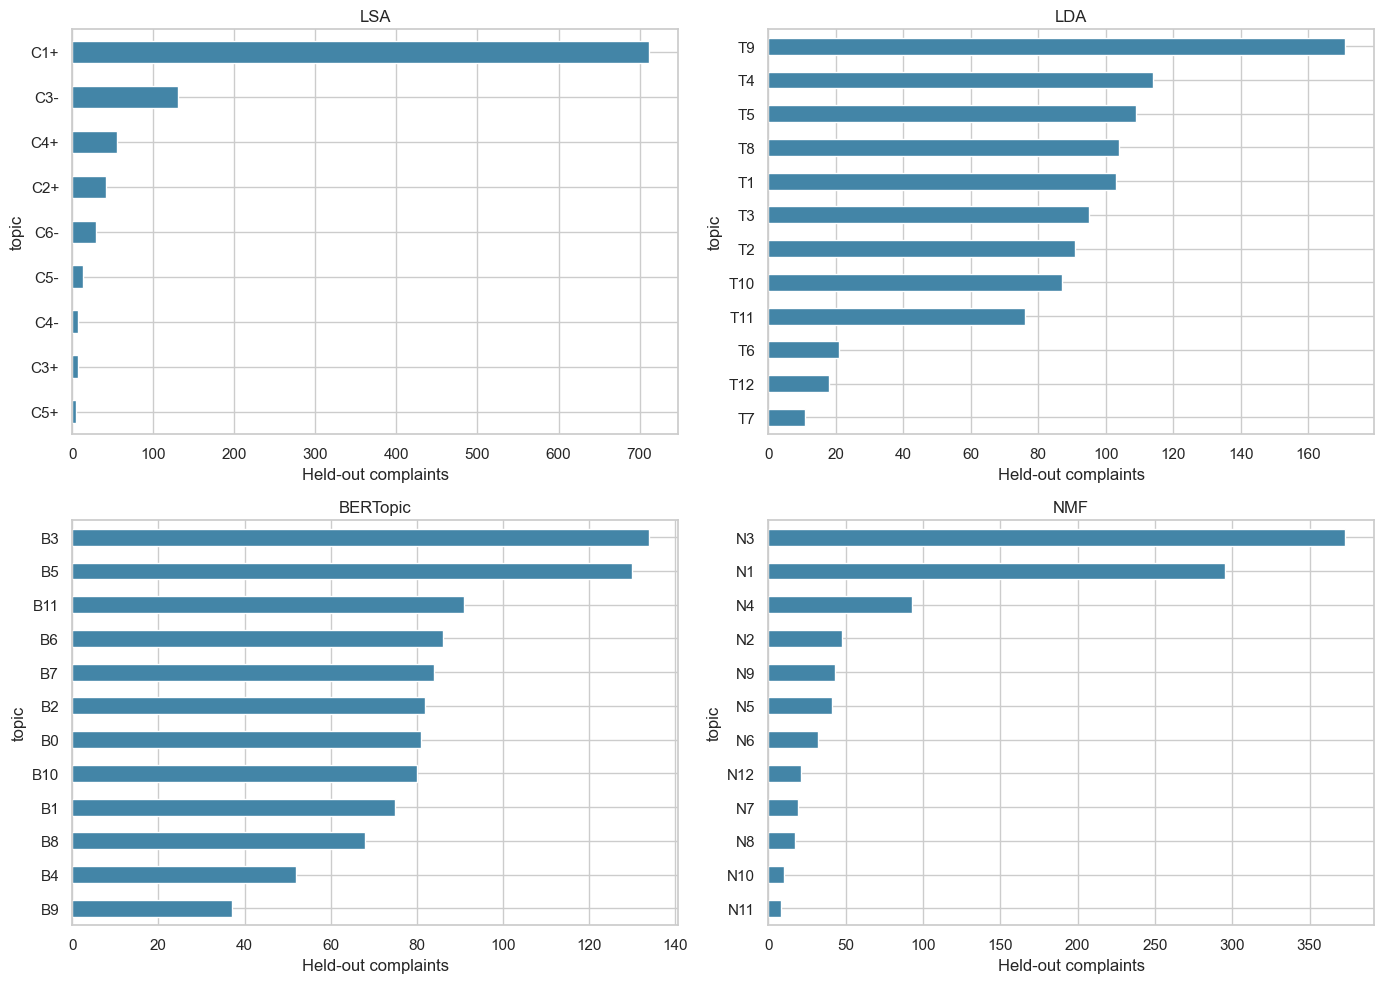

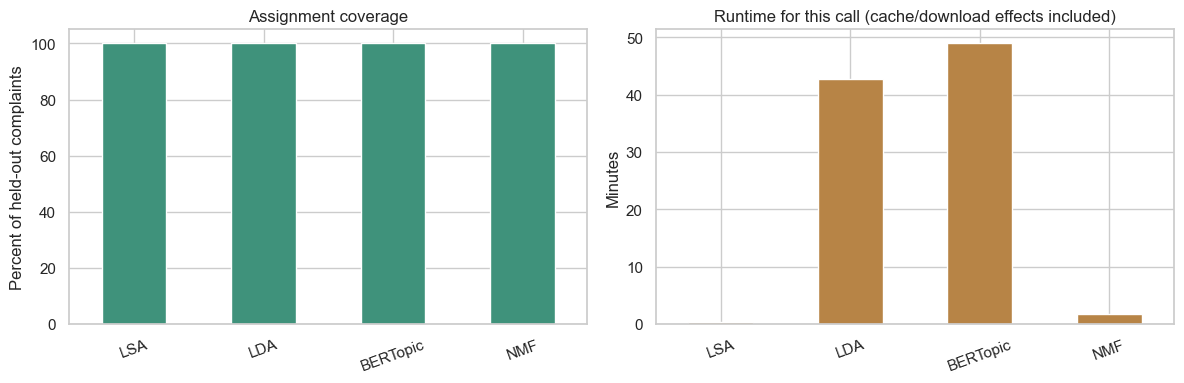

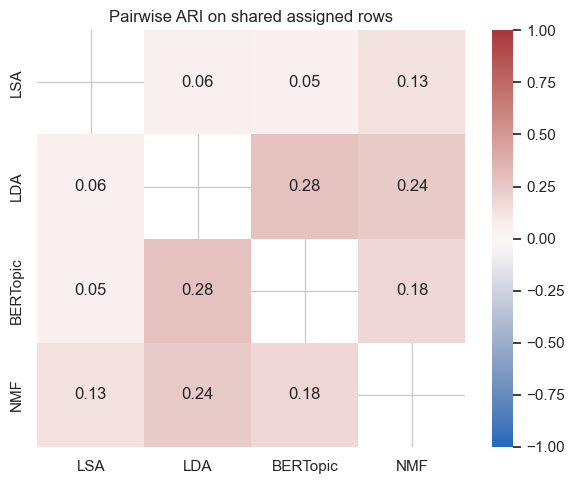

Saved figures: C:\Users\123wi\OneDrive\Desktop\duits uni\data analysis\analysis_results\run_20260924_114526_79d8e5\figures


In [14]:
sns.set_theme(style="whitegrid")

def save_figure(fig, name):
    fig.tight_layout()
    fig.savefig(OUT_DIR / "figures" / f"{name}.png", dpi=160, bbox_inches="tight")
    fig.savefig(OUT_DIR / "figures" / f"{name}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

if completed:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, model in zip(axes.flat, ["LSA", "LDA", "BERTopic", "NMF"]):
        ax.set_title(model)
        if model not in completed:
            ax.text(0.5, 0.5, MODEL_STATUS[model]["status"], ha="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue
        counts = MODEL_RESULTS[model]["assignments"].topic.value_counts()
        # Show largest 14 and aggregate the rest so every evaluated row is represented.
        if len(counts) > 15:
            counts = pd.concat([counts.iloc[:14], pd.Series({"other topics": counts.iloc[14:].sum()})])
        counts.sort_values().plot.barh(ax=ax, color="#4385a7")
        ax.set_xlabel("Held-out complaints")
    save_figure(fig, "topic_sizes")

    plot_summary = summary_df[summary_df.model.isin(completed)].set_index("model")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    (plot_summary.coverage * 100).plot.bar(ax=axes[0], color="#3f927b", rot=20)
    axes[0].set(title="Assignment coverage", ylabel="Percent of held-out complaints", ylim=(0, 105), xlabel="")
    plot_summary.runtime_minutes.plot.bar(ax=axes[1], color="#b78446", rot=20)
    axes[1].set(title="Runtime for this call (cache/download effects included)", ylabel="Minutes", xlabel="")
    save_figure(fig, "coverage_and_runtime")

    if len(completed) > 1 and not agreement_df.empty:
        matrix = pd.DataFrame(np.nan, index=completed, columns=completed)
        for _, row in agreement_df.iterrows():
            matrix.loc[row.model_a, row.model_b] = row.ARI
            matrix.loc[row.model_b, row.model_a] = row.ARI
        if matrix.notna().any().any():
            fig, ax = plt.subplots(figsize=(6, 5))
            sns.heatmap(matrix, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
            ax.set_title("Pairwise ARI on shared assigned rows")
            save_figure(fig, "agreement_ari")
print("Saved figures:", OUT_DIR / "figures")

## 13. Optional: assign the full corpus in batches
Here we can use the fitted local models on every saved complaint. Turn on
`RUN_FULL_CORPUS_ASSIGNMENT` in section 1 to run this stage. The models remain trained on the sample.
This can take a long time, especially sentence embeddings. All four models run locally and are included when they have completed successfully.

Each batch is saved atomically as JSONL with original identifiers, model topics and scores.
Completed batches are reused when rerunning this stage in the same analysis folder with the same
models. Only one batch is in RAM. No full-dataset DataFrame or dense vocabulary matrix is created.

In [15]:
RUN_FULL_CORPUS_ASSIGNMENT = False
if not RUN_FULL_CORPUS_ASSIGNMENT:
    print("Full-corpus assignment is off. Sample results are already saved.")
else:
    full_dir = OUT_DIR / "full_corpus"
    models_used = [m for m in ["LSA", "LDA", "BERTopic", "NMF"] if m in MODEL_RESULTS]
    if not models_used:
        raise RuntimeError("Run at least one local model first.")
    def sha256_file(path):
        digest = hashlib.sha256()
        with Path(path).open("rb") as handle:
            for block in iter(lambda: handle.read(1024 * 1024), b""):
                digest.update(block)
        return digest.hexdigest()
    model_paths = {"LSA": "lsa.joblib", "LDA": "lda.joblib", "BERTopic": "bertopic.pkl", "NMF": "nmf.joblib"}
    signature = {"config": CONFIG, "batch_rows": FULL_BATCH_ROWS, "models": models_used,
                 "word_features": sha256_file(OUT_DIR / "models" / "word_features.joblib"),
                 "model_hashes": {m: sha256_file(OUT_DIR / "models" / model_paths[m]) for m in models_used}}
    signature_path = full_dir / "signature.json"
    if signature_path.exists() and read_json(signature_path) != signature:
        raise ValueError("Full-corpus checkpoint belongs to different fitted models/settings. Use a new analysis run.")
    write_json(signature_path, signature)
    counts_by_model = {name: Counter() for name in models_used}
    total = 0
    records_iter = iter_records(JSONL_PATH)
    with ProcessPoolExecutor(max_workers=N_WORKERS, initializer=text_worker.initialise_worker,
                             initargs=(nltk.data.path,)) as pool:
        part = 0
        while True:
            records = list(islice(records_iter, FULL_BATCH_ROWS))
            if not records:
                break
            part += 1
            destination = full_dir / f"assignments_{part:06d}.jsonl"
            ids = [str(r["matrix_row"]) for r in records]
            if destination.exists():
                saved = list(iter_records(destination))
                if [r["doc_id"] for r in saved] != ids:
                    raise ValueError(f"Checkpoint IDs mismatch: {destination}")
            else:
                prepared_batch = prepare_texts([r["original_text"] for r in records], pool)
                frame = pd.DataFrame(prepared_batch)
                counts = vectorizer.transform(frame.lemmatised_text)
                predictions = {}
                if "LSA" in models_used:
                    predictions["LSA"] = lsa_assign(tfidf.transform(counts).astype(np.float32))
                if "LDA" in models_used:
                    predictions["LDA"] = lda_assign(counts)
                if "NMF" in models_used:
                    predictions["NMF"] = nmf_assign(tfidf.transform(counts).astype(np.float32))
                if "BERTopic" in models_used:
                    embedded = document_embeddings(frame.expanded_text.tolist(), show_progress=False)
                    predictions["BERTopic"] = bertopic_assign(frame.lemmatised_text.tolist(), embedded)
                saved = []
                for i, record in enumerate(records):
                    row = {"doc_id": ids[i], "complaint_id": record.get("complaint_id"),
                           "source_record": record.get("source_record")}
                    for model, (topics, scores) in predictions.items():
                        row[model + "_topic"] = str(topics[i])
                        score = float(np.max(scores[i]))
                        row[model + "_score"] = score if np.isfinite(score) else None
                    saved.append(row)
                temporary = destination.with_suffix(".tmp")
                write_jsonl(temporary, saved)
                temporary.replace(destination)
                del frame, counts, prepared_batch, predictions
            for row in saved:
                for model in models_used:
                    counts_by_model[model][row[model + "_topic"]] += 1
            total += len(saved)
            write_json(full_dir / "status.json", {"status": "running", "rows": total, "parts": part, "models": models_used})
            if part % 20 == 0:
                print(f"Assigned {total:,}/{SOURCE_ROWS:,}; batches are saved on disk.")
    if total != SOURCE_ROWS:
        raise RuntimeError("Full-corpus output row count mismatch.")
    full_sizes = pd.DataFrame([{"model": model, "topic": topic, "rows": count}
                              for model, sizes in counts_by_model.items() for topic, count in sizes.items()])
    full_sizes.to_csv(full_dir / "topic_sizes.csv", index=False)
    write_json(full_dir / "status.json", {"status": "complete", "rows": total, "parts": part, "models": models_used})
    print("Full-corpus rows assigned:", total)
    display(full_sizes)

Full-corpus assignment is off. Sample results are already saved.


## 14. Save the run summary
Here we record what actually ran. The most useful files are `model_comparison.csv`, the four
model topic/assignment tables, `representative_complaints.csv`, and the figures folder.
The manual-review sheet is blank for you or your professor to assess topic quality.
Saved pickle/joblib models are only for your own trusted files and matching package versions.

In [16]:
run_summary = {"source_rows": SOURCE_ROWS, "training_rows": len(train_df), "evaluation_rows": len(eval_df),
               "completed_models": completed, "model_status": MODEL_STATUS,
               "comparison_complete": len(completed) == 4, "shared_word_feature_seconds": FEATURE_SECONDS,
               "held_out_vocabulary_token_coverage": word_coverage,
               "analysis_output": str(OUT_DIR), "full_corpus_requested": RUN_FULL_CORPUS_ASSIGNMENT}
write_json(OUT_DIR / "run_summary.json", run_summary)
print("Analysis saved to:", OUT_DIR)
print("Completed models:", ", ".join(completed))
print("Four-model comparison complete:", len(completed) == 4)
display(pd.DataFrame([{"file": str(p.relative_to(OUT_DIR)), "KiB": round(p.stat().st_size / 1024, 1)}
                      for p in sorted((OUT_DIR / "tables").glob("*.csv"))]))

Analysis saved to: C:\Users\123wi\OneDrive\Desktop\duits uni\data analysis\analysis_results\run_20260924_114526_79d8e5
Completed models: LSA, LDA, BERTopic, NMF
Four-model comparison complete: True


,file,KiB
0,tables\analysis_vocabulary.csv,3400.9
1,tables\BERTopic_assignments.csv,39.2
2,tables\BERTopic_topics.csv,1.5
3,tables\BERTopic_training_topic_sizes.csv,0.1
4,tables\LDA_assignments.csv,56.9
5,tables\LDA_topics.csv,1.2
6,tables\LSA_assignments.csv,49.6
7,tables\LSA_topics.csv,1.9
8,tables\manual_topic_review.csv,106.9
9,tables\model_comparison.csv,1.0


## Sources and interpretation
- [LSA / truncated SVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html)
- [LDA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html)
- [Mini-batch NMF](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.MiniBatchNMF.html)
- [Topic extraction with NMF and LDA](https://scikit-learn.org/stable/auto_examples/applications/plot_topics_extraction_with_nmf_lda.html)
- [BERTopic](https://maartengr.github.io/BERTopic/)
- [Sentence Transformers](https://www.sbert.net/)

The four models have different assumptions but share the training and evaluation rows.
Topic interpretations require human inspection. Keeping stop words is deliberate and can make
frequency-based keywords less distinctive. Compare useful themes, not only numerical agreement.


## 15. Export this notebook and its saved outputs to PDF
**Press Ctrl+S before running this cell.** The export reads the saved notebook, including its existing
text, code, tables and figures. It does not run the expensive models again. Empty optional cells do not
block export, and any earlier error output stays visible in the report. The export cell's old output
is excluded. If you renamed or moved this notebook, update `NOTEBOOK_PATH` in the first cell.
An HTML copy is also saved; if automatic PDF export fails, open it and use your browser's Print → Save as PDF.

In [ ]:
# NOTEBOOK_PDF_EXPORT
import nbformat
from nbconvert import HTMLExporter
from pathlib import Path

NOTEBOOK_PATH = Path("complaints_analysis.ipynb")
OUT_DIR = Path("C:\Users\123wi\OneDrive\Desktop\duits uni\data analysis\New folder")
if not NOTEBOOK_PATH.is_file():
    raise FileNotFoundError(f"Save this notebook and check NOTEBOOK_PATH: {NOTEBOOK_PATH}")
saved_notebook = nbformat.read(str(NOTEBOOK_PATH), as_version=4)
for cell in saved_notebook.cells:
    if cell.cell_type == "code" and ("pdf-export" in cell.metadata.get("tags", []) or "# NOTEBOOK_PDF_EXPORT" in cell.source):
        cell.outputs = []
        cell.execution_count = None
if not any(c.get("outputs") for c in saved_notebook.cells if c.cell_type == "code"):
    print("WARNING: the saved notebook contains no outputs. Press Ctrl+S, then export again.")
html_exporter = HTMLExporter()
html_exporter.exclude_input = False
html_exporter.exclude_output = False
html_body, _ = html_exporter.from_notebook_node(saved_notebook)
html_body = html_body.replace("</head>", "<style>pre {white-space:pre-wrap!important;overflow-wrap:anywhere;} @media print {.jp-OutputArea-output {overflow:visible!important;}}</style></head>")
html_path = OUT_DIR / "complaints_analysis.html"
html_path.write_text(html_body, encoding="utf-8")
snapshot = OUT_DIR / "complaints_analysis_saved_snapshot.ipynb"
nbformat.write(saved_notebook, str(snapshot))
pdf_path = OUT_DIR / "complaints_analysis.pdf"
export_script = """
import sys, asyncio, nbformat
from pathlib import Path
from nbconvert import WebPDFExporter
if sys.platform == 'win32':
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
nb = nbformat.read(sys.argv[1], as_version=4)
exporter = WebPDFExporter(allow_chromium_download=True)
exporter.paginate = True
pdf, _ = exporter.from_notebook_node(nb)
Path(sys.argv[2]).write_bytes(pdf)
"""
print("Exporting saved notebook outputs; no analysis cells are being rerun.")
export = subprocess.run([sys.executable, "-c", export_script, str(snapshot), str(pdf_path)],
                        capture_output=True, text=True)
if export.returncode == 0:
    print("PDF saved:", pdf_path)
else:
    print("Automatic PDF export failed:")
    print(export.stderr[-2500:])
    print("If needed: %pip install 'nbconvert[webpdf]>=7.16,<8'")
    print("Open the HTML file and use Print > Save as PDF:", html_path)
print("HTML saved:", html_path)